[Feature Selection Explanation Section](#feature)

The LLM ChatGPT was used to help refactor code and add comments

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from IPython.display import display
from tab_hero.dataio.tokenizer import ChartTokenizer

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from sklearn.metrics import adjusted_rand_score
from itertools import product
from scipy.stats import spearmanr
from sklearn.feature_selection import f_classif

import random

In [2]:
project_root = Path.cwd()
sys.path.insert(0, str(project_root / "src"))

from tab_hero.dataio.tab_format import load_tab
data_dir = Path("../data/processed") 
tab_files = list(data_dir.glob("*.tab"))
SEED = 42

In [3]:
features_path = Path("../features.csv")

df_features = pd.read_csv(features_path)
df_features.head()


,content_hash,difficulty_id,instrument_id,genre_id,song_id,duration_sec,rms_energy_mean,rms_energy_std,amplitude_envelope_min,amplitude_envelope_max,...,inter_note_ms_std,inter_note_ms_median,inter_note_ms_p25,inter_note_ms_p75,sustain_ratio,chord_ratio,fret_entropy,hopo_ratio,star_power_ratio,tap_ratio
0,00068c50bf7a2a95,0,2,7,3631,163.480091,1.891090,1.430148,0.402069,4.052784,...,742.686223,830.0,820.0,830.0,0.041667,0.000000,1.107923,0.000000,0.104167,0.000000
1,00044d42d97be12d,0,2,4,1694,194.292971,1.687803,0.795066,0.098820,2.682918,...,564.478392,1060.0,1050.0,1085.0,0.378378,0.000000,0.986289,0.000000,0.189189,0.000000
2,0005aa02866dddf6,0,2,1,2663,313.620317,1.692548,0.409827,0.087721,2.114662,...,473.929208,730.0,720.0,740.0,0.075269,0.000000,1.488865,0.997312,0.169355,0.000000
3,0003cad26b028e39,1,0,1,1470,285.826032,1.766457,0.513506,0.056087,2.944388,...,415.654713,360.0,240.0,490.0,0.356021,0.031414,1.367438,0.942408,0.116928,0.057592
4,0005cc1d3cbc5253,2,1,3,340,247.118367,3.104284,1.243821,0.271522,6.126035,...,580.585199,250.0,250.0,510.0,0.111905,0.690476,1.583723,0.990476,0.119048,0.002381


In [4]:
tab_files = sorted(tab_files)
random.seed(SEED)
sample_files = random.sample(tab_files, k=300)

In [5]:
rows = []
errors = []

for p in sample_files:
    try:
        data = load_tab(p)
        row = dict(data.__dict__)
        rows.append(row)
    except Exception as e:
        
        errors.append((p.name, str(e)))


In [6]:
# ========================
# Type Conversions
# ========================

instrument_names = {
    0: "Lead",
    1: "Bass",
    2: "Rhythm",
    3: "Keys",
}

difficulty_names = {
    0: "Easy",
    1: "Medium",
    2: "Hard",
    3: "Expert",
}

In [7]:
# ==============================================================
# Section Level Feature Usage Map
# Each section defines a feature set plus a short rationale.
# This keeps the notebook consistent and avoids redefining use_cols.
# ==============================================================


# -----------------------------
# Section 2, Instrument analysis
# Goal: compare how instruments differ in "play feel" and chart construction.
# Chosen: gameplay mechanics + density, because these reflect how a part plays.
# Excluded: audio features, because they are song level and identical across instruments.
# -----------------------------
sec2_features = [
    "notes_per_second_mean",
    "n_notes",
    "chord_ratio",
    "sustain_ratio",
    "fret_entropy",
    "hopo_ratio",
    "tap_ratio",
    "star_power_ratio"
]



# -----------------------------
# Section 4, Global structure and redundancy
# Goal: understand redundancy and latent axes across the full feature space.
# Chosen: include all modeling relevant numeric features, including audio,
# because PCA and hierarchical clustering should reveal cross family structure.
# Excluded: amplitude envelope mins and maxes are often redundant with rms features,
# but kept here only if you want to verify redundancy empirically.
# -----------------------------
sec4_features = [
    # Song meta
    "duration_sec",
    "tempo_bpm",

    # Density and timing
    "n_notes",
    "notes_per_second_mean",
    "inter_note_ms_mean",
    "inter_note_ms_std",
    "inter_note_ms_median",
    "inter_note_ms_p25",
    "inter_note_ms_p75",

    # Gameplay mechanics
    "sustain_ratio",
    "chord_ratio",
    "fret_entropy",
    "hopo_ratio",
    "tap_ratio",
    "star_power_ratio",

    # Audio descriptors
    "rms_energy_mean",
    "rms_energy_std",
    "amplitude_envelope_min",
    "amplitude_envelope_max",
    "amplitude_envelope_range",
    "mel_rms_mean",
    "mel_rms_std",
    "spectral_centroid_mean",
]

# -----------------------------
# Section 7, Global clustering across all charts
# Goal: discover broad chart archetypes using both gameplay and audio context.
# Chosen: density and timing features (not statistics), gameplay mechanics and some audio features,
# and drop duration_sec because it can dominate clusters by song length.
# Keep audio because it helps reveal song profile driven clusters.
# -----------------------------
sec7_features = [
    "duration_sec", 
    "tempo_bpm", 
    "n_notes", 
    "notes_per_second_mean",
    "inter_note_ms_mean", 
    "inter_note_ms_std", 
    "sustain_ratio", 
    "chord_ratio",
    "fret_entropy", 
    "hopo_ratio", 
    "tap_ratio", 
    "star_power_ratio",
    "mel_rms_mean", 
    "mel_rms_std", 
    "spectral_centroid_mean"
]
# If tempo_bpm is reliable in your dataset, you can add it back.


# -----------------------------
# Section 8a, KS difficulty separability per feature
# Goal: check whether each feature alone separates difficulty distributions.
# Chosen: your original key set, remove tempo_bpm if it is constant or 0.
# -----------------------------
sec8a_features = [
    "notes_per_second_mean",
    "inter_note_ms_mean",
    "inter_note_ms_std",
    "chord_ratio",
    "sustain_ratio",
    "fret_entropy",
    "hopo_ratio",
    "tap_ratio",
    "tempo_bpm"
]


# -----------------------------
# Section 8b, Nearest neighbor adjacency across difficulties
# Goal: test whether local geometry respects ordinal difficulty progression.
# Chosen: difficulty shaping structural features only.
# Removed: audio features because they distort difficulty neighborhood structure.
# Removed: duration_sec because it clusters by song length rather than difficulty.
# -----------------------------
sec8b_features = [
    "n_notes",
    "notes_per_second_mean",
    "inter_note_ms_mean",
    "inter_note_ms_std",
    "sustain_ratio",
    "chord_ratio",
    "fret_entropy",
    "hopo_ratio",
    "tap_ratio",
    "star_power_ratio",
    "tempo_bpm"
]


# -----------------------------
# Section 9, Play styles within the same difficulty
# Goal: find style subtypes inside one difficulty label.
# Chosen: structural gameplay + timing, because style is chart construction.
# Removed: audio features because they are constant across instruments and can create false styles.
# -----------------------------
sec9_features = [
    "notes_per_second_mean",
    "inter_note_ms_mean",
    "inter_note_ms_std",
    "chord_ratio",
    "sustain_ratio",
    "fret_entropy",
    "hopo_ratio",
    "tap_ratio",
]


# -----------------------------
# Section 10a, Instrument specific difficulty drift visualization
# Goal: show how density scales with difficulty separately per instrument.
# Chosen: notes_per_second_mean because it is the clearest difficulty proxy.
# -----------------------------
sec10a_features = ["notes_per_second_mean"]


# -----------------------------
# Section 10b, Instrument conditioned drift metrics
# Goal: quantify instrument drift within each difficulty level.
# Chosen: drift features that represent gameplay and timing mechanics.
# -----------------------------
sec10b_features = [
    "notes_per_second_mean",
    "inter_note_ms_mean",
    "chord_ratio",
    "sustain_ratio",
    "hopo_ratio",
    "tap_ratio",
    "fret_entropy",
]


# -----------------------------
# Section 11, Feature selection and pruning
# Goal: identify redundancy, instability, and relevance for modeling.
# Chosen: keep the features you actually plan to model with,
# including audio features used for genre conditioning.
# -----------------------------
sec11_features = [
    "notes_per_second_mean",
    "inter_note_ms_mean",
    "inter_note_ms_std",
    "chord_ratio",
    "sustain_ratio",
    "fret_entropy",
    "hopo_ratio",
    "tap_ratio",
    "mel_rms_mean",
    "mel_rms_std",
    "spectral_centroid_mean",
    "tempo_bpm"
]


# -----------------------------
# Section 12, Genre analysis
# Goal: evaluate whether current features can separate genres and support clustering.
# Chosen: audio descriptors plus structural gameplay features,
# because genre is primarily audio driven but chart style may also correlate.
# -----------------------------
sec12_features = [
    "notes_per_second_mean",
    "inter_note_ms_mean",
    "inter_note_ms_std",
    "chord_ratio",
    "sustain_ratio",
    "fret_entropy",
    "hopo_ratio",
    "tap_ratio",
    "mel_rms_mean",
    "mel_rms_std",
    "spectral_centroid_mean",
    "tempo_bpm"
]

In [8]:
def clean_df(df: pd.DataFrame, cols, extra_cols=None) -> pd.DataFrame:
    """Select columns, replace inf with NaN, drop rows with missing values."""
    cols = list(cols)
    if extra_cols:
        cols = list(dict.fromkeys(list(extra_cols) + cols))
    return df[cols].replace([np.inf, -np.inf], np.nan).dropna()

def standardize(X):
    """Z-score standardize features."""
    return StandardScaler().fit_transform(X)

def plot_box_by_difficulty(df, y_col, title, xlabel, ylabel):
    diffs = sorted(df["difficulty_id"].dropna().unique())
    
    groups = [
        df.loc[df["difficulty_id"] == d, y_col].dropna()
        for d in diffs
    ]
    
    labels = [difficulty_names.get(d, str(d)) for d in diffs]

    plt.figure()
    plt.boxplot(groups, showfliers=False)
    plt.xticks(range(1, len(labels) + 1), labels)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()


def kmeans_labels(scaled, k, random_state=0, n_init=10):
    """KMeans labels for standardized data."""
    return KMeans(n_clusters=k, random_state=random_state, n_init=n_init).fit_predict(scaled)

def silhouette_over_k(scaled, ks, random_state=0, n_init=10):
    """Silhouette sweep for KMeans over a list or range of k."""
    sil = []
    for k in ks:
        labels = kmeans_labels(scaled, k, random_state=random_state, n_init=n_init)
        sil.append(silhouette_score(scaled, labels))
    return sil

def plot_silhouette_curve(ks, sil, title, xlabel="K", ylabel="Silhouette", marker="o"):
    plt.plot(list(ks), sil, marker=marker)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def pca2(scaled, n_components=2, random_state=0):
    return PCA(n_components=n_components, random_state=random_state).fit_transform(scaled)

def plot_pca_clusters(Z, labels, title, s=6, cbar_label="Cluster"):
    plt.scatter(Z[:, 0], Z[:, 1], c=labels, s=s)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.colorbar(label=cbar_label)
    plt.tight_layout()
    plt.show()

def plot_heatmap(
    M,
    xlabels,
    ylabels,
    title,
    cbar_label=None,
    figsize=(6, 5),
    aspect="auto",
    xrot=0,
    ha=None,
    vmin=None,
    vmax=None,
):
    plt.figure(figsize=figsize)
    plt.imshow(M, aspect=aspect, vmin=vmin, vmax=vmax)
    if ha is None:
        ha = "right" if xrot else "center"
    plt.xticks(range(len(xlabels)), [str(x) for x in xlabels], rotation=xrot, ha=ha)
    plt.yticks(range(len(ylabels)), [str(y) for y in ylabels])
    plt.colorbar(label=cbar_label if cbar_label else "")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_bar(categories, values, title, xlabel=None, ylabel=None, rotate=90, figsize=None):
    if figsize:
        plt.figure(figsize=figsize)
    plt.bar([str(c) for c in categories], values)
    if rotate:
        plt.xticks(rotation=rotate)
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def cluster_labels(cols):
    X = df_features[cols].replace([np.inf, -np.inf], np.nan).dropna()
    scaled = standardize(X.values)
    return KMeans(n_clusters=8, random_state=0, n_init=10).fit_predict(scaled)

def bootstrap_std(x, n=30, frac=0.8):
    rng = np.random.default_rng(0)
    vals = []
    for _ in range(n):
        idx = rng.choice(len(x), size=int(frac * len(x)), replace=True)
        vals.append(np.nanmean(x[idx]))
    return float(np.std(vals))


In [9]:
df_tabs = pd.DataFrame(rows)
df_tabs.head()

,mel_spectrogram,sample_rate,hop_length,note_tokens,difficulty_id,instrument_id,content_hash,genre_id,song_id
0,"[[-1.1279297, -1.1279297, -1.1279297, -1.12792...",22050,256,"[1, 503, 518, 631, 642, 70, 518, 631, 642, 70,...",2,0,c940117355a8f420,1,6052
1,"[[-2.8808594, -2.9042969, -3.0117188, -3.13281...",22050,256,"[1, 503, 505, 631, 640, 35, 505, 631, 640, 35,...",2,0,237b10b35cabd811,1,472
2,"[[-2.2167969, -2.2167969, -2.2167969, -2.21679...",22050,256,"[1, 440, 504, 631, 642, 36, 505, 631, 642, 36,...",2,0,07e1e41e1003f1b1,13,5934
3,"[[-2.6796875, -2.6796875, -2.6796875, -2.67968...",22050,256,"[1, 503, 504, 632, 653, 77, 504, 632, 639, 40,...",1,2,e924eea23ea77a15,7,370
4,"[[-2.6230469, -2.6230469, -2.6230469, -2.62304...",22050,256,"[1, 393, 504, 631, 642, 84, 505, 631, 642, 51,...",1,2,563cfff61d1a085a,1,3592


<h1>1. Difficulty analysis </h1>

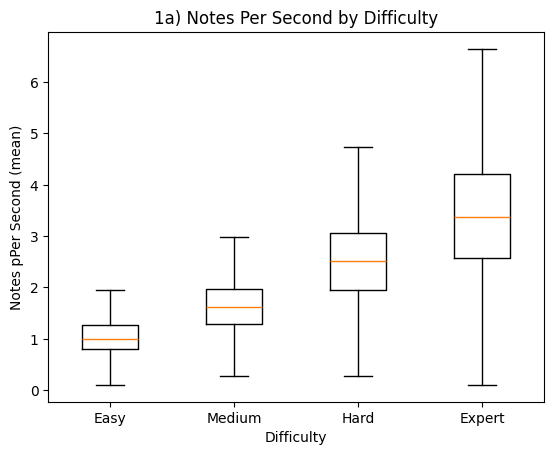

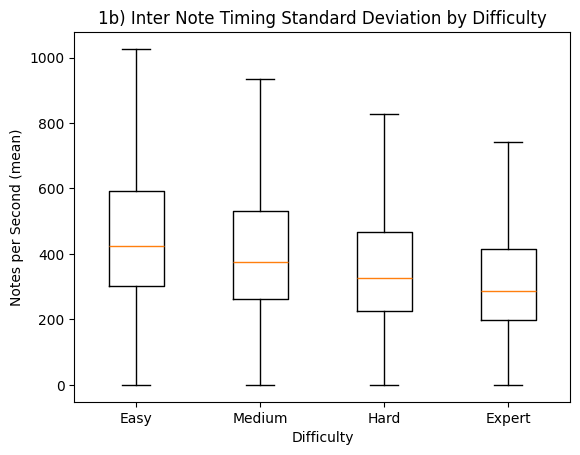

In [10]:
plot_box_by_difficulty(df_features, "notes_per_second_mean", "1a) Notes Per Second by Difficulty", "Difficulty", "Notes pPer Second (mean)")
plot_box_by_difficulty(df_features, "inter_note_ms_std", "1b) Inter Note Timing Standard Deviation by Difficulty", "Difficulty", "Notes per Second (mean)")

The following analysis confirms the assumption that the higher the difficulty, the faster the notes appear. The box plots confirm this with higher difficulties showing a higher notes_per_second_mean and a lower inter_note_ms_std. Interestingly enough, the higher difficulties have more variable notes_per_second_means. This likely reflects the fact that the notes in higher difficulties tend to more accurately reflect the notes of the song. As difficulties get lower, the note order needs to be summarized to appear at an easier pace while still capturing the pattern of the song being played.

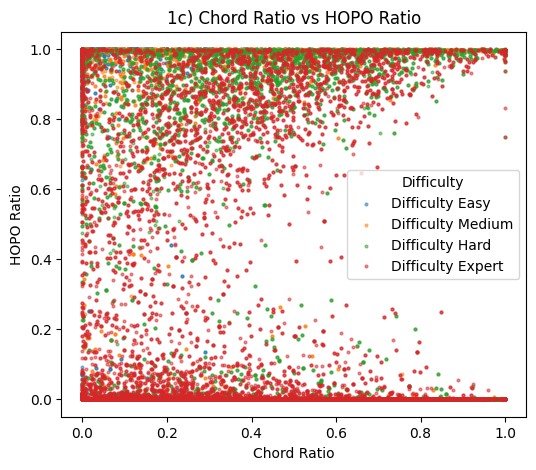

In [11]:
difficulty_levels = sorted(df_features["difficulty_id"].dropna().unique())

plt.figure(figsize=(6, 5))

for d in difficulty_levels:
    mask = (
        df_features["chord_ratio"].notna() &
        df_features["hopo_ratio"].notna() &
        (df_features["difficulty_id"] == d)
    )

    plt.scatter(
        df_features.loc[mask, "chord_ratio"],
        df_features.loc[mask, "hopo_ratio"],
        s=4,
        alpha=0.5,
        label=f"Difficulty {difficulty_names.get(d, str(d))}"
    )

plt.xlabel("Chord Ratio")
plt.ylabel("HOPO Ratio")
plt.title("1c) Chord Ratio vs HOPO Ratio")
plt.legend(title="Difficulty")
plt.show()

The Chord Ratio vs HOPO Ratio aims to compare how mechanical structure evolves with difficulty and whether difficulty reflects different stylistic meanings. The results appear generally noisy, but a few trends can be extgracted. Many of the charts concentrate at 0 or 1 for HOPO with very sparse points in between. This indicates that charts are either heavily HOPO based or hardly use it at all. Regions with boderate to high Chord vs HOPO ratios skew towards higher difficulty levels. 

<h1>2. Instrument Analysis</h1>

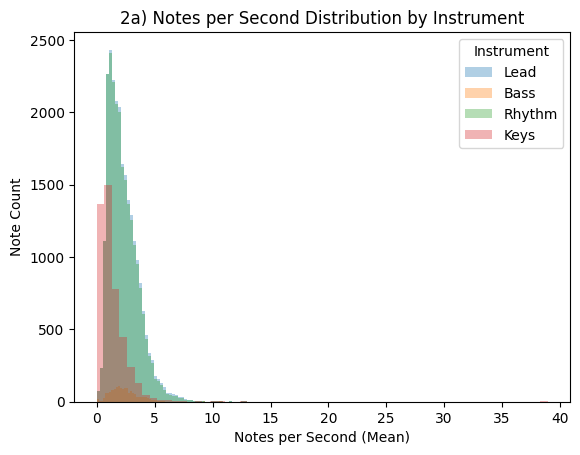

In [12]:
insts = sorted(df_features["instrument_id"].dropna().unique())

for inst in insts:
    vals = df_features.loc[
        df_features["instrument_id"] == inst,
        "notes_per_second_mean"
    ].dropna()

    plt.hist(
        vals,
        bins=60,
        alpha=0.35,
        label=instrument_names.get(inst, str(inst))
    )

plt.xlabel("Notes per Second (Mean)")
plt.ylabel("Note Count")
plt.title("2a) Notes per Second Distribution by Instrument")
plt.legend(title="Instrument")
plt.show()

This histogram reveals that Lead and Rhythm charts generally have higher notes per second than Bass and Keys. Bass charts tend to concentrate at lower densities, suggesting simpler rhythmic structures while Lead and Rhythm are much denser, indicating more complicated patterns. It reveals that note density is instrument dependent and provides a strong signal for modeling instrument specific chart behavior.

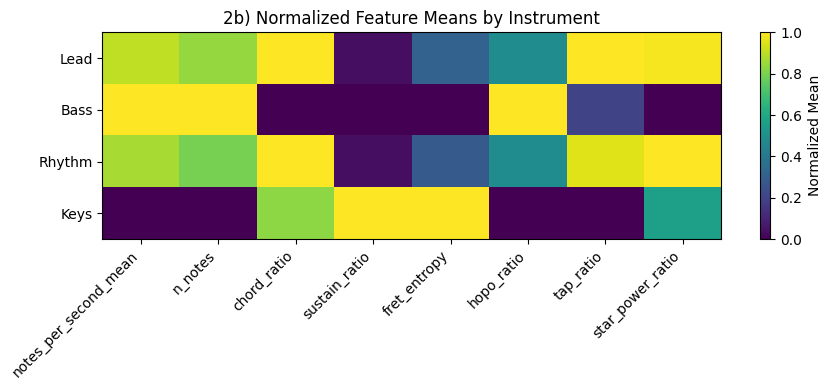

In [13]:
means = df_features.groupby("instrument_id")[sec2_features].mean().sort_index()
norm = (means - means.min()) / (means.max() - means.min())

plot_heatmap(
    norm.values,
    xlabels=sec2_features,
    ylabels=[instrument_names.get(i, str(i)) for i in norm.index],
    title="2b) Normalized Feature Means by Instrument",
    cbar_label="Normalized Mean",
    figsize=(9, 4),
    xrot=45,
    ha="right",
)

Lead and Rhythm have higher note density, chord ratio, HOPO ratio, and tap ratio, reinforcing the idea that these instruments contain complex and varied patterns. Bass exhibits high note density but very low chord, sustain, and HOPO ratios, suggesting simpler, more repetitive structures focused on single note lines. Keys stand out with very high sustain ratio and fret entropy but low HOPO and tap usage, implying longer held notes and more evenly distributed fret usage rather than fast technical passages. Overall, instruments have distinct structural signatures in feature space, confirming that instrument conditioning is important for modeling and generation.

<h1>3. Density Profiling</h1>

In [14]:
def time_bins_from_tokens(tokens, tokenizer):
    toks = np.array(tokens, dtype=np.int32)
    time_mask = (toks >= tokenizer._time_token_start) & (toks < tokenizer._time_token_end)
    return (toks[time_mask] - tokenizer._time_token_start).astype(np.int32)

def rolling_density(time_bins, window=80):
    if len(time_bins) == 0:
        return np.array([])
    inv = 1.0 / np.clip(np.array(time_bins, dtype=np.float32), 1e-6, None)
    if inv.size < window:
        window = inv.size
    return np.convolve(inv, np.ones(window) / window, mode="valid")


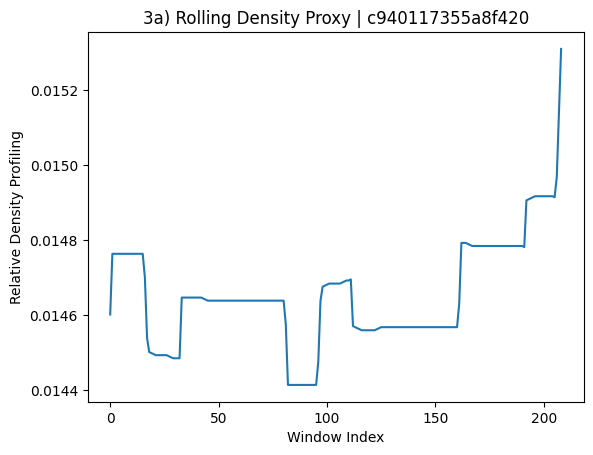

In [15]:
tokenizer = ChartTokenizer()

r = df_tabs.iloc[0]
tb = time_bins_from_tokens(r["note_tokens"], tokenizer)
rd = rolling_density(tb, window=80)

plt.plot(rd)
plt.xlabel("Window Index")
plt.ylabel("Relative Density Profiling")
plt.title(f"3a) Rolling Density Proxy | {r.get('content_hash','')}")
plt.show()

The rolling density proxy shows relativey stable note densite throughout most of the chart, with small localized dips and gradual increases. The sensity slightly decreases in early and midsections then trends upwards towards then end, indicating a ramp-up in the later half of the track. Overall, the chart appears rhythmically consistent with modest structural variation rather than dramatic burst sections.

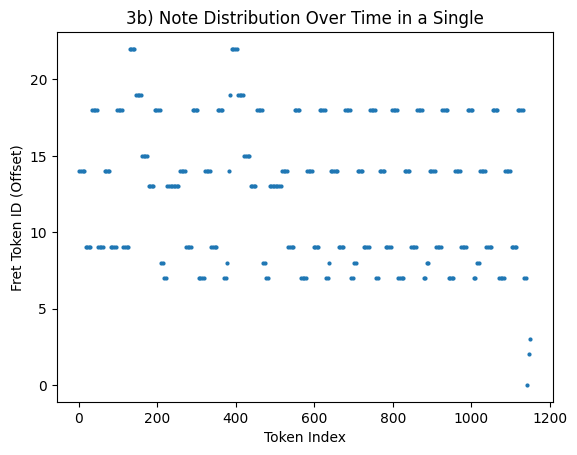

In [16]:
r = df_tabs.iloc[0]
toks = np.array(r["note_tokens"], dtype=np.int32)

fret_mask = (toks >= tokenizer._fret_token_start) & (toks < tokenizer._fret_token_end)
fret_positions = np.where(fret_mask)[0]
fret_ids = toks[fret_mask] - tokenizer._fret_token_start

plt.scatter(fret_positions, fret_ids, s=4)
plt.xlabel("Token Index")
plt.ylabel("Fret Token ID (Offset)")
plt.title("3b) Note Distribution Over Time in a Single")
plt.show()

This plot contains repeated fret patterns over time, as indicated by the strong horizontal banding. This means the same fret tokens are reused consistently, which is appropriate for a song, as they are structured works rather than sparatic pieces. This indicates that charts have sequential structure and pattern reuse, not just overall density characteristics. For tab generation, this means the model must learn to produce consistent fret patterns that maintain local structural coherence as well as capture gradual intensity changes across sections.

<h1>4. Feature Reduction</h1>

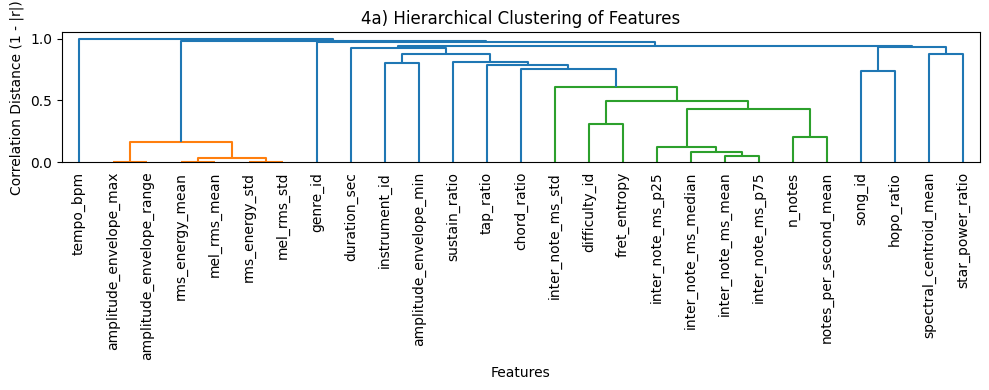

In [17]:
num_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
corr = df_features[num_cols].corr().fillna(0.0)

dist = 1 - corr.abs()
dist_condensed = squareform(dist.values, checks=False)
Z = linkage(dist_condensed, method="average")

plt.figure(figsize=(10, 4))
dendrogram(Z, labels=num_cols, leaf_rotation=90)
plt.xlabel("Features")
plt.ylabel("Correlation Distance (1 - |r|)")
plt.title("4a) Hierarchical Clustering of Features")
plt.tight_layout()
plt.show()

Hierarchical clustering was performed using the absolute Pearson correlation between all numeric features to identify redundancy and latent structure in the feature space. The Pearson correlation coefficient measures the strength and direction of a linear relationship between two variables, ranging from -1 to 1 with a distance metric of 1 - |r| applied to enable grouping of positive and negative correlations. In this scale, 0 indicates no relationship while 1 indicates a strong relationship. The resulting dendogram shows clear feature families: audio energy statistics such as RMS and amplitude envelope metrics cluster tightly, indicating redundancy; timing dispersion measures group together, reflecting shared rhythmic structure; and density related metrics such as note rate and total note count form a compact cluster. In contrast, gameplay specific structural features including chord ratio, HOPO ratio, tap ratio, and fret entropy appear more separated, suggesting they capture distinct stylistic or mechanical characteristics. Overall, the dendrogram demonstrates meaningful internal structure, highlighting both redundant groups suitable for reduction and structurally complementary features valuable for modeling.

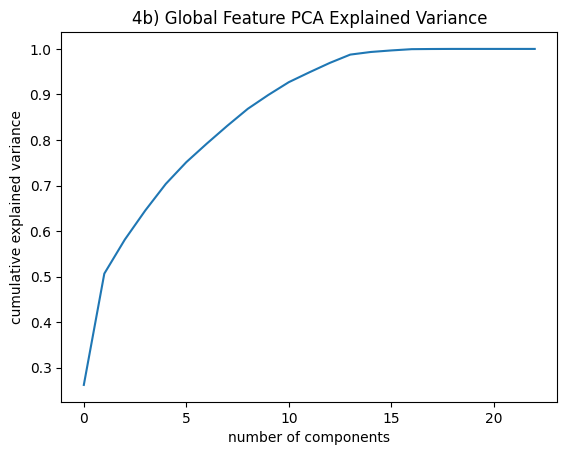

,PC1,PC2
inter_note_ms_mean,0.305781,0.268829
inter_note_ms_p75,0.290348,0.254377
inter_note_ms_median,0.284483,0.258752
mel_rms_std,0.280746,0.317099
rms_energy_std,0.280746,0.317099
mel_rms_mean,0.270661,0.300086
rms_energy_mean,0.270661,0.300086
inter_note_ms_p25,0.270290,0.248390
amplitude_envelope_max,0.258352,0.297887
amplitude_envelope_range,0.258337,0.297897


,PC1,PC2
mel_rms_std,0.280746,0.317099
rms_energy_std,0.280746,0.317099
rms_energy_mean,0.270661,0.300086
mel_rms_mean,0.270661,0.300086
amplitude_envelope_range,0.258337,0.297897
amplitude_envelope_max,0.258352,0.297887
inter_note_ms_mean,0.305781,0.268829
inter_note_ms_median,0.284483,0.258752
inter_note_ms_p75,0.290348,0.254377
inter_note_ms_p25,0.270290,0.248390


In [18]:
X = clean_df(df_features, sec4_features)
scaled = standardize(X.values)
pca = PCA().fit(scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("number of components")
plt.ylabel("cumulative explained variance")
plt.title("4b) Global Feature PCA Explained Variance")
plt.show()

loadings = pd.DataFrame(pca.components_[:2], columns=sec4_features, index=["PC1", "PC2"]).T
display(loadings.abs().sort_values("PC1", ascending=False).head(10))
display(loadings.abs().sort_values("PC2", ascending=False).head(10))


The PCA results show that most variance in the dataset is captured by a small number of components, with roughly six to eight components explaining the majority of variability. This indicates substantial feature redundancy. The first principal component reflects a general structural intensity axis driven by timing dispersion and energy magnitude features, while the second component emphasizes audio energy variability with partial overlap from timing measures. Rather than forming completely independent gameplay and audio axes, the dominant components blend density, timing, and energy effects. Overall, chart intensity and loudness dynamics account for much of the variance structure, while gameplay mechanics contribute additional but comparatively smaller sources of variation.

<a id='feature'></a>
<h2>Feature Selection for Clustering</h2>


Hierarchical correlation clustering and PCA reveal clear feature families and substantial redundancy among variables relating to timing and gameplay. Density related metrics cluster together, while the same is true for RMS and amplitude based features. Selecting one representative from each correlated group reduces redundancy while preserving interpretability and coverage of the dominant variance structure.

<b>notes_per_second_mean</b> represents overall chart density and technical intensity. PCA indicates that density and timing dispersion features contribute strongly to the first principal component, making this a meaningful proxy for gameplay speed and structural intensity. <b>chord_ratio</b> encodes structural complexity and pattern variation. Although moderately related to other gameplay metrics, it captures a distinct aspect of mechanical differentiation. <b>sustain_ratio</b> captures note length structure and rhythmic flow, adding complementary information beyond raw density.
    
<b>spectral_centroid_mean</b> represents tonal brightness, adding a timbral dimension largely separate from chart density features. <b>rms_energy_mean</b> represents overall audio intensity and dynamic variation. 
. PCA shows RMS based features load strongly on early principal components, reflecting a major axis of variation associated with energy magnitude, though not entirely independent from timing features.

Together, this reduced feature set spans the primary latent dimensions identified by PCA: chart density and structural complexity, 
and audio energy with timbral brightness.

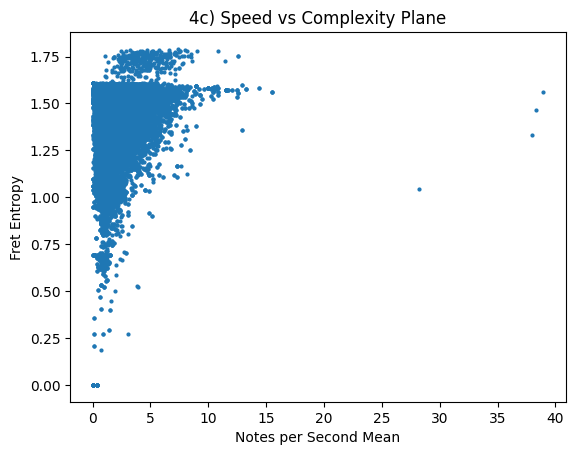

In [19]:
speed = df_features["notes_per_second_mean"]
complexity = df_features["fret_entropy"]
s = df_features[["notes_per_second_mean", "fret_entropy"]].dropna()
plt.scatter(s["notes_per_second_mean"], s["fret_entropy"], s=4)
plt.xlabel("Notes per Second Mean")
plt.ylabel("Fret Entropy")
plt.title("4c) Speed vs Complexity Plane")
plt.show()

This plot shows the relationship between chart speed, measured by notes per second, and structural complexity, measured by fret entropy. Most charts cluster in a moderate speed range with relatively high fret entropy, indicating that even slower charts often use a broad distribution of frets. As speed increases, fret entropy generally remains high, suggesting that higher density charts do not sacrifice fret diversity. The triangular shape at lower speeds shows that slow charts can range from very simple, low entropy patterns to more varied structures, while very high speed charts tend to maintain moderate to high complexity. It reveals that speed and complexity are related without being tightly coupled, indicating independence. 

<h1>5. Extreme Value and Structure Discovery</h1>

In [20]:
out = df_features.copy()
out["is_top_density"] = out["notes_per_second_mean"] >= out["notes_per_second_mean"].quantile(0.99)
ct = pd.crosstab(out["instrument_id"], out["is_top_density"])
display(ct)

is_top_density,False,True
instrument_id,,
0,23641,276
1,1491,11
2,23165,222
3,4552,25


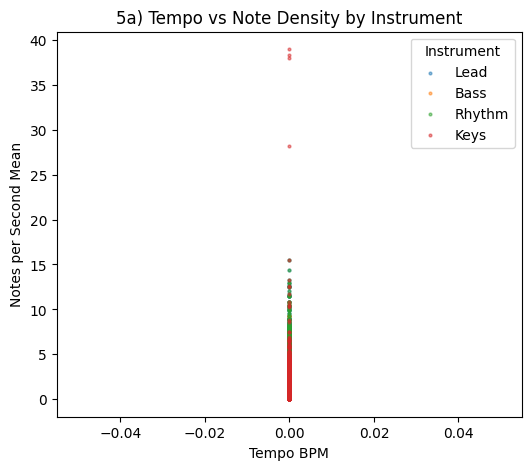

In [21]:
plt.figure(figsize=(6, 5))
for inst in sorted(df_features["instrument_id"].dropna().unique()):
    mask = (
        df_features["tempo_bpm"].notna() &
        df_features["notes_per_second_mean"].notna() &
        (df_features["instrument_id"] == inst)
    )
    plt.scatter(
        df_features.loc[mask, "tempo_bpm"],
        df_features.loc[mask, "notes_per_second_mean"],
        s=4,
        alpha=0.5,
        label=instrument_names.get(inst, str(inst))
    )
plt.xlabel("Tempo BPM")
plt.ylabel("Notes per Second Mean")
plt.title("5a) Tempo vs Note Density by Instrument")
plt.legend(title="Instrument")
plt.show()

This plot indicates a clear issue with the tempo feature rather than a meaningful musical relationship. Nearly all points are concentrated around zero on the tempo axis, forming a vertical line, which suggests that tempo_bpm is either failing to compute correctly or defaulting to zero for most charts. Because tempo shows almost no variation, there is no visible relationship between tempo and note density in this plot.

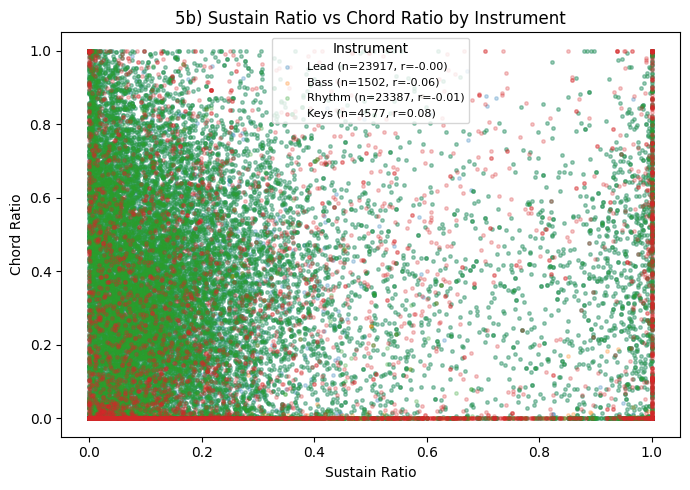

In [22]:
plt.figure(figsize=(7, 5))

for inst in sorted(df_features["instrument_id"].dropna().unique()):
    sub = df_features[
        (df_features["instrument_id"] == inst) &
        df_features["sustain_ratio"].notna() &
        df_features["chord_ratio"].notna()
    ]
    if len(sub) < 5:
        continue

    x = sub["sustain_ratio"].to_numpy()
    y = sub["chord_ratio"].to_numpy()

    # Pearson correlation
    r = np.corrcoef(x, y)[0, 1] if len(sub) > 1 else np.nan

    name = instrument_names.get(inst, str(inst))
    label = f"{name} (n={len(sub)}, r={r:.2f})" if np.isfinite(r) else f"{name} (n={len(sub)})"

    plt.scatter(x, y, s=6, alpha=0.25, label=label)

plt.xlabel("Sustain Ratio")
plt.ylabel("Chord Ratio")
plt.title("5b) Sustain Ratio vs Chord Ratio by Instrument")
plt.legend(title="Instrument", fontsize=8)
plt.tight_layout()
plt.show()

This plot shows a wide spread of sustain ratio and chord ratio values across all instruments, with a heavy concentration at lower sustain values and full coverage across chord usage. The near zero Pearson correlations indicate no strong linear relationship between sustain and chord ratios, suggesting charts can independently vary how many notes are held versus how many are chords. Rhythm and Lead occupy broad portions of the feature space, though this likely reflects their larger sample sizes. Bass appears more concentrated toward lower chord usage, while Keys include several instances of higher sustain values, consistent with longer held note structures. Overall, sustain usage and chord density behave largely as independent gameplay dimensions across instruments.

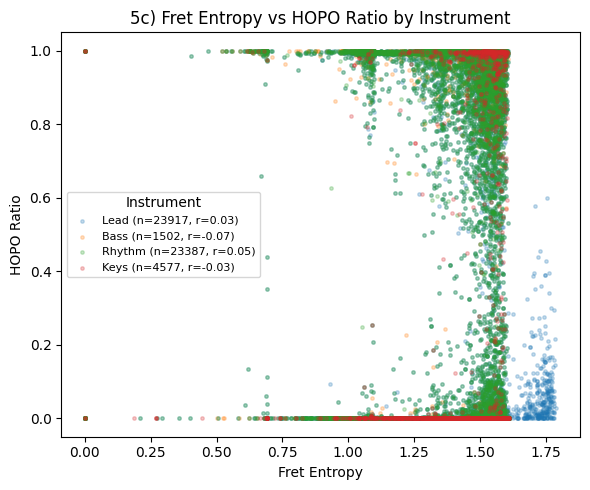

In [23]:
plt.figure(figsize=(6, 5))

for inst in sorted(df_features["instrument_id"].dropna().unique()):
    sub = df_features[
        (df_features["instrument_id"] == inst) &
        df_features["fret_entropy"].notna() &
        df_features["hopo_ratio"].notna()
    ]
    if len(sub) < 5:
        continue

    x = sub["fret_entropy"].to_numpy()
    y = sub["hopo_ratio"].to_numpy()

    # Pearson correlation
    r = np.corrcoef(x, y)[0, 1] if len(sub) > 1 else np.nan

    name = instrument_names.get(inst, str(inst))
    label = f"{name} (n={len(sub)}, r={r:.2f})" if np.isfinite(r) else f"{name} (n={len(sub)})"

    plt.scatter(x, y, s=6, alpha=0.25, label=label)

plt.xlabel("Fret Entropy")
plt.ylabel("HOPO Ratio")
plt.title("5c) Fret Entropy vs HOPO Ratio by Instrument")
plt.legend(title="Instrument", fontsize=8)
plt.tight_layout()
plt.show()

The plot shows that fret entropy and HOPO ratio are not tightly coupled, as reflected by near zero Pearson correlations across instruments. Most charts cluster at high fret entropy values, indicating broad fret utilization, while HOPO usage frequently polarizes near 0 or 1, matching patterns observed in earlier analysis. Lead charts concentrate at high entropy but generally lower HOPO ratios, suggesting varied fret usage without heavy reliance on HOPO mechanics. Rhythm and Keys span a wider range of HOPO values at high entropy, while Bass appears more concentrated in lower entropy and lower HOPO regions. Overall, fret diversity and HOPO usage represent largely independent mechanical dimensions with visible distributional differences across instruments.

###### <h1>6. Data Distribution Analysis</h1>

difficulty_id,Easy,Medium,Hard,Expert
instrument_id,,,,
Lead,5841,5837,5841,6398
Bass,373,374,372,383
Rhythm,5786,5780,5784,6037
Keys,1138,1139,1141,1159


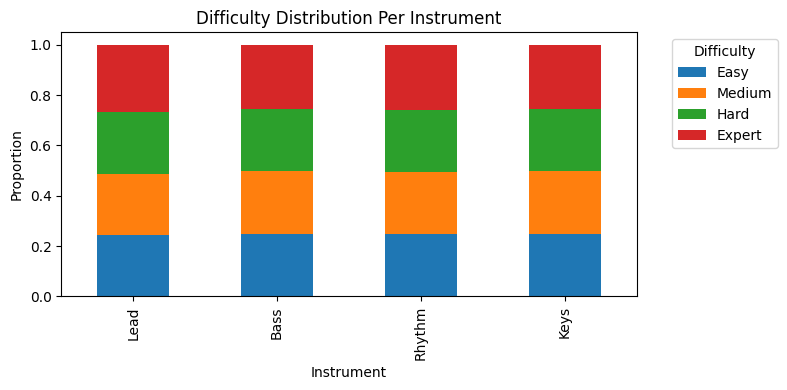

In [24]:
ct = pd.crosstab(df_features["instrument_id"], df_features["difficulty_id"])

ct.index = ct.index.map(lambda x: instrument_names.get(x, str(x)))
ct.columns = ct.columns.map(lambda x: difficulty_names.get(x, str(x)))
display(ct)

ct_norm = ct.div(ct.sum(axis=1), axis=0)

# Plot
ct_norm.plot(kind="bar", stacked=True, figsize=(8, 4))

plt.ylabel("Proportion")
plt.title("Difficulty Distribution Per Instrument")
plt.xlabel("Instrument")
plt.legend(title="Difficulty", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

This chart passes the sanity check that each instrument is represented equally among difficulties, verifying the effectiveness of the feature generation.


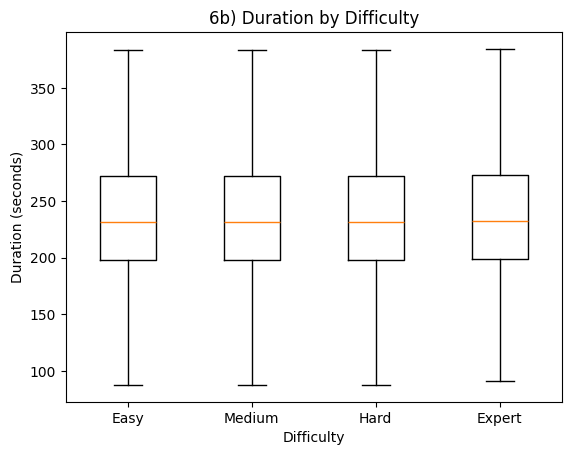

In [25]:
plot_box_by_difficulty(df_features, "duration_sec", "6b) Duration by Difficulty", "Difficulty", "Duration (seconds)")

This box plot verifies that all difficulties have the same duration recorded, preventing biased results based on difficulties.

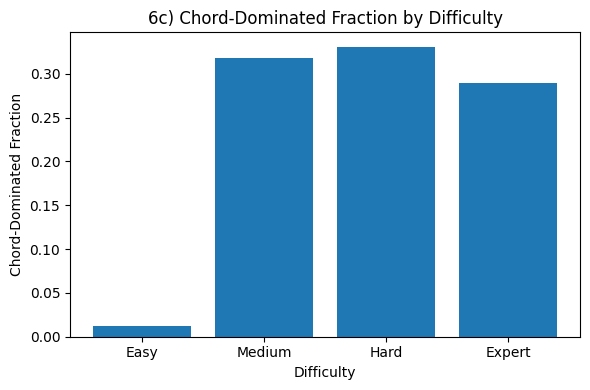

In [26]:
frac_by_diff = (
    df_features
    .assign(chord_dominated=df_features["chord_ratio"] > 0.5)
    .groupby("difficulty_id")["chord_dominated"]
    .mean()
    .sort_index()
)

# Map difficulty IDs to names
labels = [difficulty_names.get(d, str(d)) for d in frac_by_diff.index]

plt.figure(figsize=(6, 4))
plt.bar(labels, frac_by_diff.values)

plt.xlabel("Difficulty")
plt.ylabel("Chord-Dominated Fraction")
plt.title("6c) Chord-Dominated Fraction by Difficulty")
plt.tight_layout()
plt.show()

The plot shows that chord dominated charts, defined as those with chord ratio greater than 0.5, are extremely rare at Easy but become substantially more common beginning at Medium and remain elevated through Hard and Expert. The sharp increase from Easy to Medium suggests a structural shift in chart composition at the first difficulty transition. However, the fraction does not increase steadily beyond Medium and slightly decreases at Expert, indicating that higher difficulty is not simply driven by increasing chord usage. Instead, chord dominance appears to function as an early threshold feature introduced at intermediate difficulty, while additional mechanics likely drive further increases in complexity

<h1>7. Cluster Analysis</h1>

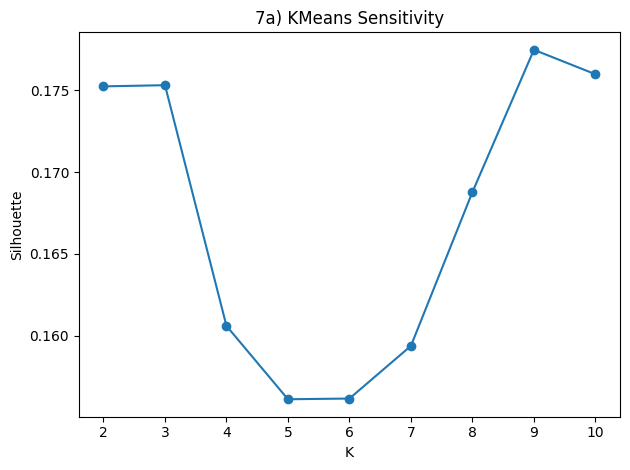

In [27]:
X = clean_df(df_features, sec7_features)
scaled = standardize(X.values)

ks = range(2, 11)
sil = silhouette_over_k(scaled, ks, random_state=0, n_init=10)

plot_silhouette_curve(ks, sil, title="7a) KMeans Sensitivity")

The silhouette curve shows that clustering quality is modest across all tested values of k, with scores peaking around k = 9 and remaining relatively similar for k = 2 and k = 3. The dip between k = 4 and k = 6 suggests weaker cluster separation in that range, meaning the data does not naturally partition cleanly into that many groups. The gradual increase toward k = 8 to 9 indicates slightly better defined substructure at higher cluster counts, though overall silhouette values remain low, implying overlapping feature distributions rather than sharply separated clusters. Overall, the feature space appears to contain soft structure rather than strongly distinct natural groupings. 


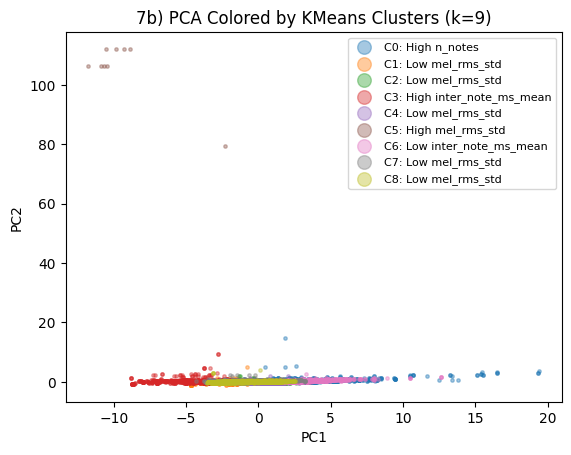

Cluster centroids
         duration_sec  tempo_bpm    n_notes  notes_per_second_mean  \
cluster                                                              
0            345.7740        0.0  1528.1709                 4.7270   
1            233.7968        0.0   275.6019                 1.1853   
2            226.9233        0.0   537.2900                 2.4108   
3            256.6935        0.0   148.5238                 0.5743   
4            222.3254        0.0   566.6941                 2.5937   
5            356.3076        0.0   133.2222                 0.5526   
6            256.0166        0.0   942.0310                 3.6940   
7            280.4259        0.0   516.5499                 1.8745   
8            254.5954        0.0   427.9009                 1.6986   

         inter_note_ms_mean  inter_note_ms_std  sustain_ratio  chord_ratio  \
cluster                                                                      
0                  224.1238           234.6421         

In [28]:
best_k = ks[np.argmax(sil)] 
kmeans = KMeans(n_clusters=best_k, random_state=0, n_init=10)
labels = kmeans.fit_predict(scaled)

pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(scaled)

# Compute centroids in original feature space
centroid = (
    pd.DataFrame(X.values, columns=sec7_features)
    .assign(cluster=labels)
    .groupby("cluster")[sec7_features]
    .mean()
)

# Compute global mean centroid
global_mu = centroid.mean(axis=0)

cluster_feature_map = {}

for c in centroid.index:
    # Difference from global centroid
    delta = centroid.loc[c] - global_mu
    
    # Feature with largest deviation
    dominant_feature = delta.abs().sort_values(ascending=False).index[0]
    
    # Determine direction of deviation
    direction = "High" if delta[dominant_feature] > 0 else "Low"
    
    cluster_feature_map[c] = f"C{c}: {direction} {dominant_feature}"

plt.figure()

for c in sorted(np.unique(labels)):
    idx = labels == c
    plt.scatter(
        Z[idx, 0],
        Z[idx, 1],
        s=6,
        alpha=0.4,
        label=cluster_feature_map.get(c, f"C{c}")
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"7b) PCA Colored by KMeans Clusters (k={best_k})")
plt.legend(markerscale=4, fontsize=8)
plt.show()

print("Cluster centroids")
print(centroid.round(4))

The clusters primarily separate along density and gameplay mechanics rather than audio features. One cluster clearly represents extreme high speed charts, while others distinguish between HOPO heavy technical styles, chord dominant strumming styles, and sustain heavy slower charts. Several clusters capture moderate density variations combined with different mechanical balances, reflecting meaningful gameplay archetypes. One cluster is strongly influenced by corrupted audio features, indicating preprocessing artifacts rather than stylistic structure. Overall, clustering reveals distinct structural gameplay styles driven mainly by note density, HOPO usage, chord ratio, and sustain behavior.

In [29]:
X = clean_df(df_features, sec7_features)
scaled = standardize(X.values)
labels = KMeans(n_clusters=best_k, random_state=0).fit_predict(scaled)

tmp = df_features.loc[X.index, ["difficulty_id"]].copy()
tmp["cluster"] = labels
ct = pd.crosstab(tmp["cluster"], tmp["difficulty_id"])
print(ct)


difficulty_id     0     1     2     3
cluster                              
0                12   531  3338  5656
1              9744  1298   174    78
2                13    58   514  1291
3              2202  1312   696   493
4                 2     2     2     3
5               121  5683  4217  2440
6               593  1265  1107   923
7                53   144   311   907
8               398  2837  2779  2186


<h1>8. Difficulty Ambiguity and Overlap Analysis </h1>

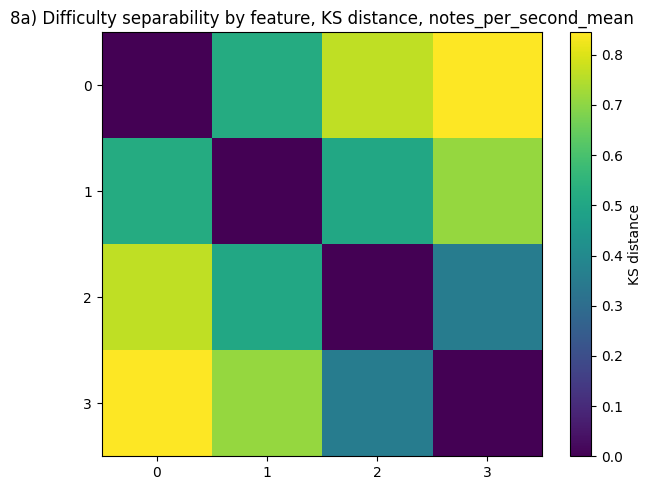

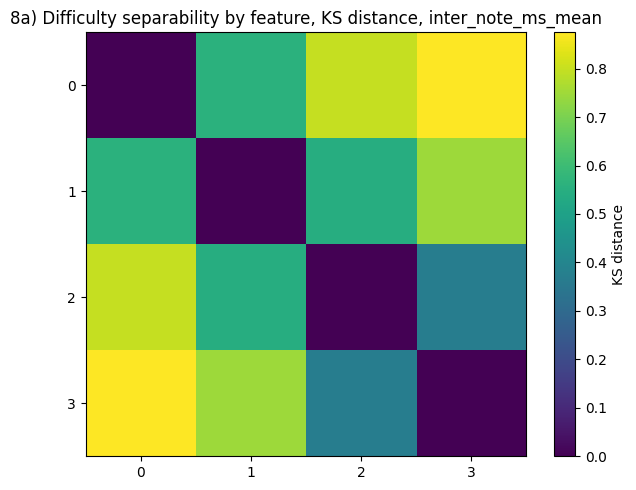

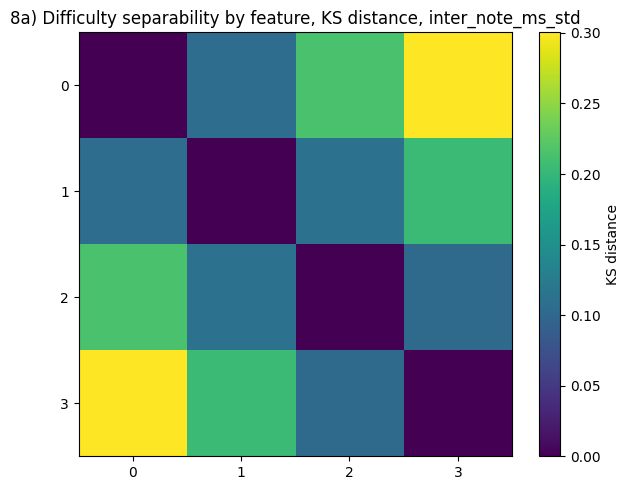

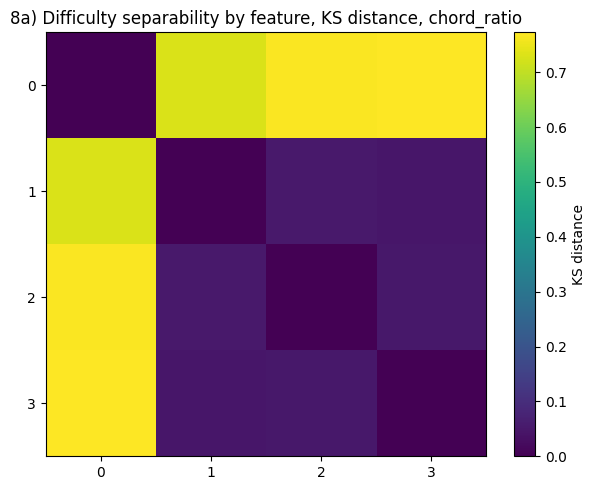

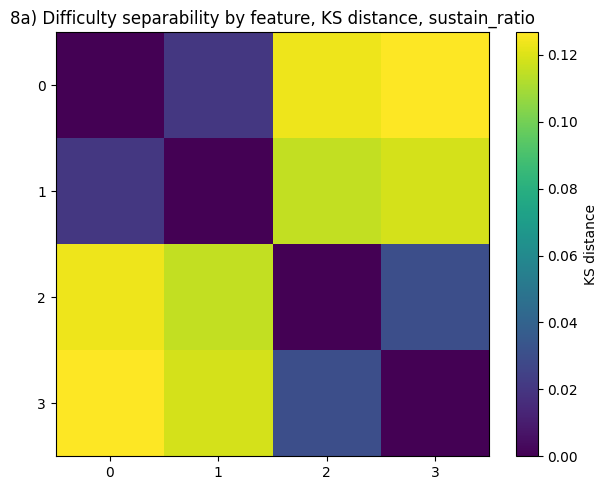

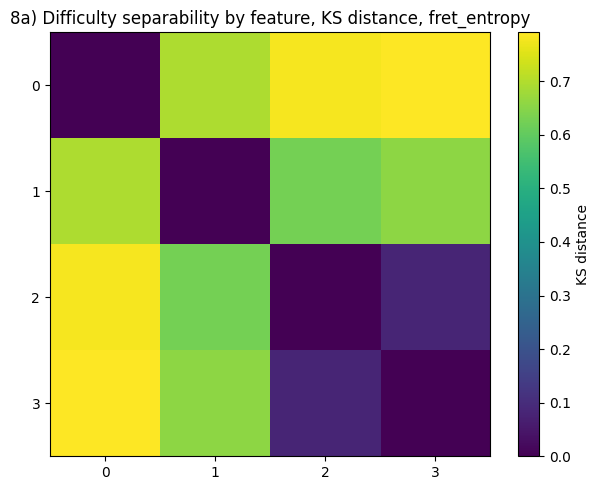

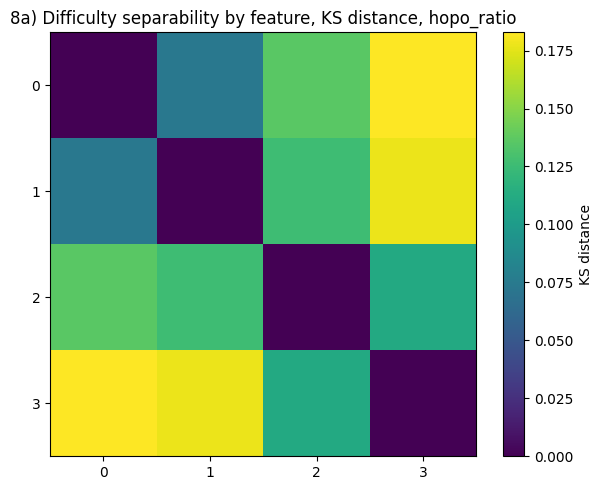

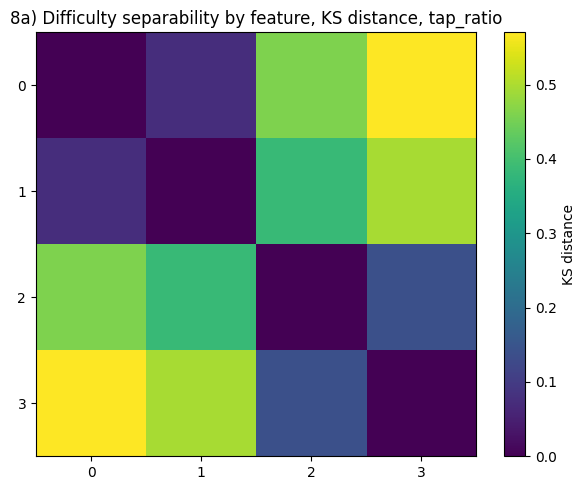

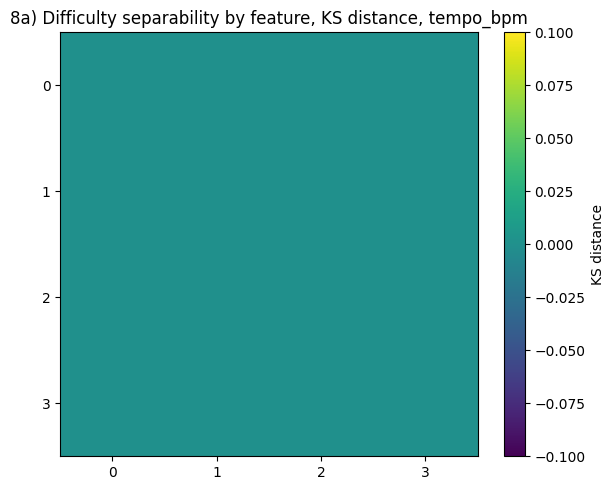

In [30]:
diffs = sorted(df_features["difficulty_id"].dropna().unique())

def ks_statistic(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 5 or len(b) < 5:
        return np.nan
    a = np.sort(a); b = np.sort(b)
    x = np.sort(np.unique(np.concatenate([a, b])))
    cdf_a = np.searchsorted(a, x, side="right") / len(a)
    cdf_b = np.searchsorted(b, x, side="right") / len(b)
    return float(np.max(np.abs(cdf_a - cdf_b)))

for feat in sec8a_features:
    M = np.zeros((len(diffs), len(diffs)), dtype=float)
    for i, di in enumerate(diffs):
        ai = df_features.loc[df_features["difficulty_id"] == di, feat].dropna()
        for j, dj in enumerate(diffs):
            bj = df_features.loc[df_features["difficulty_id"] == dj, feat].dropna()
            M[i, j] = ks_statistic(ai, bj)

    plot_heatmap(
        M,
        xlabels=[str(d) for d in diffs],
        ylabels=[str(d) for d in diffs],
        title=f"8a) Difficulty separability by feature, KS distance, {feat}",
        cbar_label="KS distance",
        figsize=(6, 5),
        xrot=0,
    )

Density and average timing features provide the strongest separation across difficulty levels, with large KS distances even between adjacent tiers. Timing variability contributes moderate separation, while mechanical features such as chord ratio, fret entropy, HOPO usage, and tap ratio provide meaningful but weaker signals. Chord ratio strongly separates Easy from higher levels but does not scale continuously beyond that point, suggesting a threshold effect. Tap ratio becomes more discriminative at higher difficulties. Sustain ratio provides limited separation overall. Tempo shows no separability, indicating it does not vary across difficulty in the current dataset. Overall, density and timing features drive the primary difficulty signal, mechanical features contribute secondary separation, and tempo contributes none.

In [31]:
D = clean_df(df_features, sec8b_features, extra_cols=["difficulty_id"])
X = D[sec8b_features].values
y = D["difficulty_id"].values

scaled = standardize(X)
nn = NearestNeighbors(n_neighbors=6).fit(scaled)
dist, idx = nn.kneighbors(scaled)

nearest_other_is_adjacent = []
for r in range(len(scaled)):
    my = y[r]
    neighbors = idx[r, 1:]
    other = [y[k] for k in neighbors if y[k] != my]
    if len(other) == 0:
        nearest_other_is_adjacent.append(np.nan)
        continue
    nearest_other = other[0]
    nearest_other_is_adjacent.append(int(abs(nearest_other - my) == 1))

rate = np.nanmean(nearest_other_is_adjacent)
print("Fraction of points whose nearest different difficulty is adjacent:", float(rate))


Fraction of points whose nearest different difficulty is adjacent: 0.9428020277241936


This means that for about 94.2 percent of charts, the closest chart in feature space that has a different difficulty label is only one difficulty level away, such as 1 vs 2 or 2 vs 3. In practice, it tells you the difficulty labels behave like a smooth ordinal scale in your features. Charts are much more likely to be confused with neighboring difficulties than with far apart ones, indicating meaningfulness in difficulty.


<h1>9. Play Styles Within the Same Label</h1>

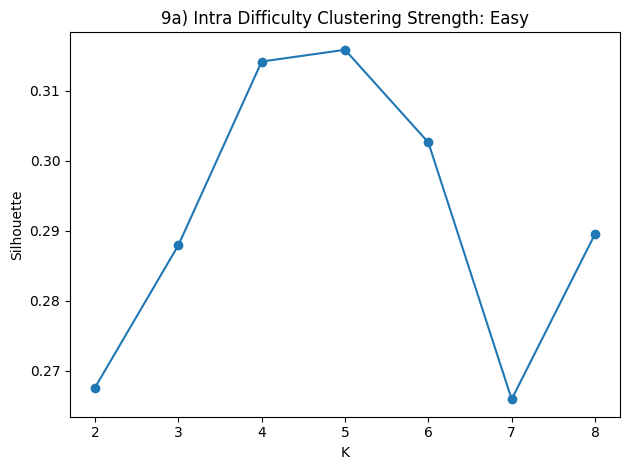

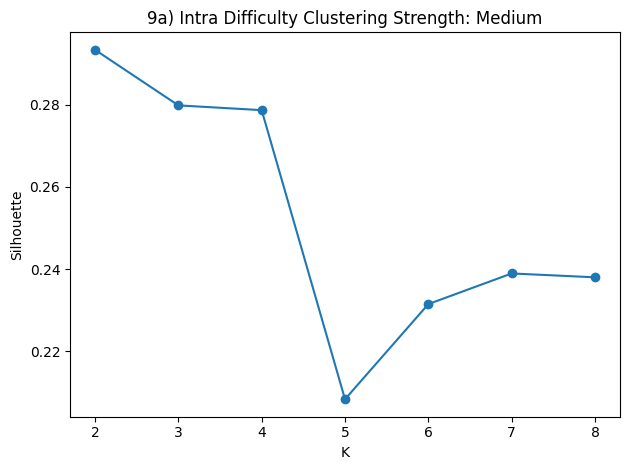

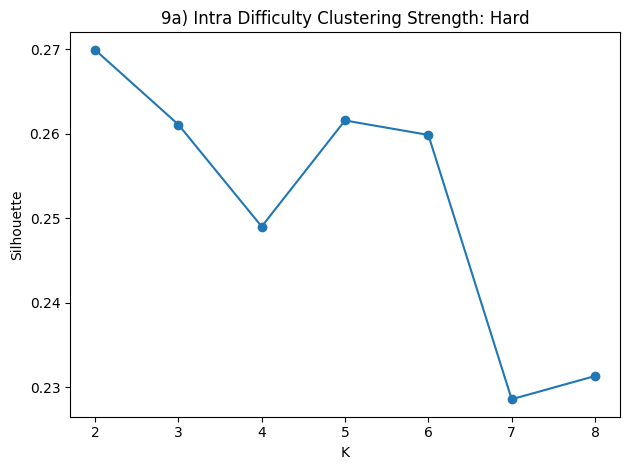

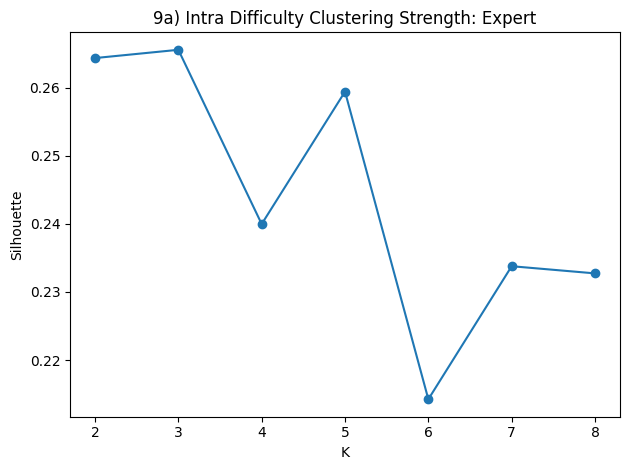

In [32]:
D = clean_df(df_features, sec9_features, extra_cols=["difficulty_id"])

ks = range(2, 9)

for d in sorted(D["difficulty_id"].unique()):
    sub = D[D["difficulty_id"] == d]
    if len(sub) < 200:
        continue

    X = sub[sec9_features].values
    scaled = standardize(X)

    sil = silhouette_over_k(scaled, ks, random_state=0, n_init=10)
    name = difficulty_names.get(d, str(d))
    plot_silhouette_curve(ks, sil, title=f"9a) Intra Difficulty Clustering Strength: {name}")

Across all four difficulties, silhouette scores are moderate, indicating overlapping but present substructure within each tier.

Easy peaks at k = 5, with similarly strong separation at k = 4. The drop at k = 7 suggests over partitioning beyond five clusters. This indicates several distinguishable Easy archetypes, but not an excessive number.

Medium clearly peaks at k = 2, then steadily declines with a sharp dip at k = 5. This suggests Medium charts form only a few broad styles, and increasing k mostly fragments overlapping structure.

Hard shows its strongest separation at k = 2, with a secondary local maximum at k = 5. The overall pattern favors small k, indicating limited but meaningful subgroup structure.

Expert peaks at k = 3, with k = 2 nearly as strong. The pronounced drop at k = 6 indicates instability at higher cluster counts. This supports the presence of a small number of Expert style subtypes rather than many distinct clusters.

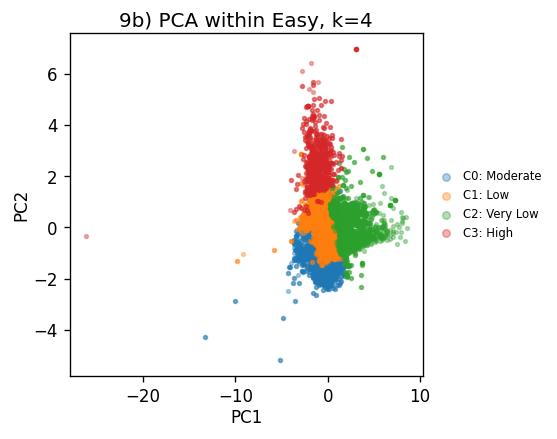


Cluster centroids within Easy
         notes_per_second_mean  inter_note_ms_mean  inter_note_ms_std  chord_ratio  sustain_ratio  fret_entropy  hopo_ratio  tap_ratio
cluster                                                                                                                               
0                       1.2133            844.0429           410.3329       0.0117         0.1121        1.1440      0.9865     0.0078
1                       1.1455            851.4574           398.0501       0.0072         0.1081        1.1327      0.0004     0.0004
2                       0.6438           1392.3778           729.8851       0.0035         0.6039        1.2281      0.0400     0.0010
3                       1.2705            765.1657           445.4928       0.3777         0.1054        1.0441      0.0759     0.0006


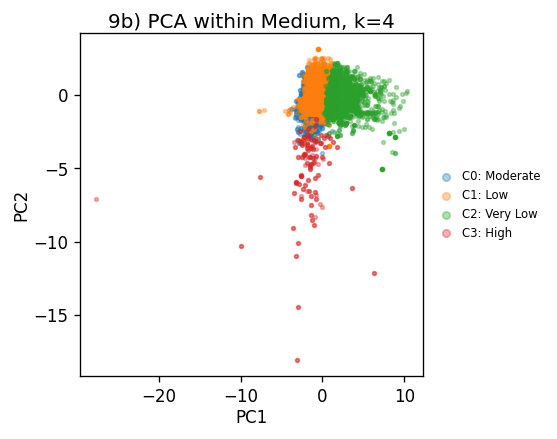


Cluster centroids within Medium
         notes_per_second_mean  inter_note_ms_mean  inter_note_ms_std  chord_ratio  sustain_ratio  fret_entropy  hopo_ratio  tap_ratio
cluster                                                                                                                               
0                       1.7967            533.2837           358.3873       0.3886         0.1034        1.3594      0.9901     0.0070
1                       1.7915            531.2320           349.4120       0.3666         0.1030        1.3393      0.0010     0.0012
2                       0.9796            972.2838           700.4189       0.3841         0.5853        1.3818      0.0429     0.0021
3                       2.5663            468.7644           395.5518       0.1644         0.2144        1.3462      0.6224     0.2432


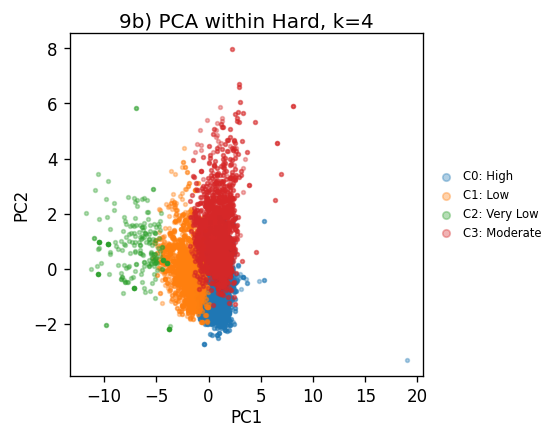


Cluster centroids within Hard
         notes_per_second_mean  inter_note_ms_mean  inter_note_ms_std  chord_ratio  sustain_ratio  fret_entropy  hopo_ratio  tap_ratio
cluster                                                                                                                               
0                       2.8636            331.2857           289.3912       0.4010         0.1121        1.4752      0.0040     0.0154
1                       1.6315            567.1442           572.7267       0.3796         0.5193        1.4988      0.0590     0.0164
2                       0.3359           2099.4024          1130.0570       0.3694         0.7498        1.3214      0.1928     0.0084
3                       2.7560            347.5270           320.8142       0.3738         0.1283        1.4970      0.8815     0.0958


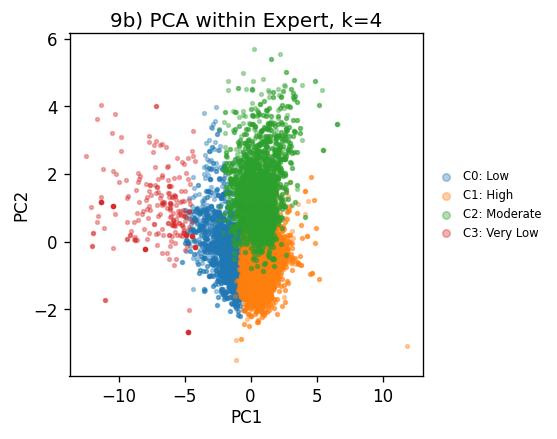


Cluster centroids within Expert
         notes_per_second_mean  inter_note_ms_mean  inter_note_ms_std  chord_ratio  sustain_ratio  fret_entropy  hopo_ratio  tap_ratio
cluster                                                                                                                               
0                       2.2180            430.4848           510.2852       0.3679         0.4703        1.4993      0.0494     0.0301
1                       4.0907            237.4876           247.3452       0.3554         0.1080        1.4977      0.0189     0.0273
2                       3.5845            276.1372           297.8464       0.3555         0.1199        1.5130      0.7992     0.1798
3                       0.3912           1880.5367          1117.8304       0.3506         0.7303        1.3532      0.1871     0.0102


In [33]:
for target_difficulty in sorted(D["difficulty_id"].unique()):

    sub = D[D["difficulty_id"] == target_difficulty]
    if len(sub) < 200:
        continue

    X = sub[sec9_features].values
    scaled = standardize(X)

    k = 4
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(scaled)

    pca = PCA(n_components=2, random_state=0)
    Z = pca.fit_transform(scaled)

    centroids = (
        sub.assign(cluster=labels)
        .groupby("cluster")[sec9_features]
        .mean()
    )

    density_order = centroids["notes_per_second_mean"].sort_values().index
    density_labels = ["Very Low", "Low", "Moderate", "High"]

    cluster_feature_map = {
        c: f"C{c}: {density_labels[i]}"
        for i, c in enumerate(density_order)
    }

    name = difficulty_names.get(target_difficulty, str(target_difficulty))

    # Compact plot
    fig, ax = plt.subplots(figsize=(4.6, 3.6), dpi=120)

    for c in sorted(np.unique(labels)):
        idx = labels == c
        ax.scatter(
            Z[idx, 0],
            Z[idx, 1],
            s=5,
            alpha=0.35,
            label=cluster_feature_map.get(c, f"C{c}")
        )

    ax.set_xlabel("PC1", labelpad=2)
    ax.set_ylabel("PC2", labelpad=2)
    ax.set_title(f"9b) PCA within {name}, k={k}", pad=4)

    # Legend outside to keep the plot area clean
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=7,
        markerscale=2,
        handletextpad=0.4,
        borderaxespad=0.0
    )

    fig.tight_layout(pad=0.5)
    plt.show()

    print(f"\nCluster centroids within {name}")
    print(centroids.round(4).to_string())

K=4 was chosen as it performed similarly across all difficulties. Across all difficulties, clusters within each tier are mainly separated by note density and sustain behavior, with additional splits based on HOPO and tap usage. In every difficulty, one cluster represents very low density, sustain heavy charts with large spacing between notes, while other clusters reflect progressively higher density and shorter spacing. Chord ratio remains relatively similar within Medium, Hard, and Expert, indicating that chord usage is not the primary factor distinguishing clusters at higher tiers.

Mechanic based differences become more important within each difficulty. Easy and Medium both contain clusters that are similar in density but differ strongly in HOPO usage, showing early stylistic variation. Hard and Expert include fast stream clusters as well as HOPO heavy technical clusters, and Expert further shows a tapping influenced subtype. Overall, the centroids indicate that density provides the main structural separation, while HOPO, tapping, and sustain create meaningful substyles within each difficulty.

# <h1>10. Instrument Conditioned Difficulty Drift </h1>

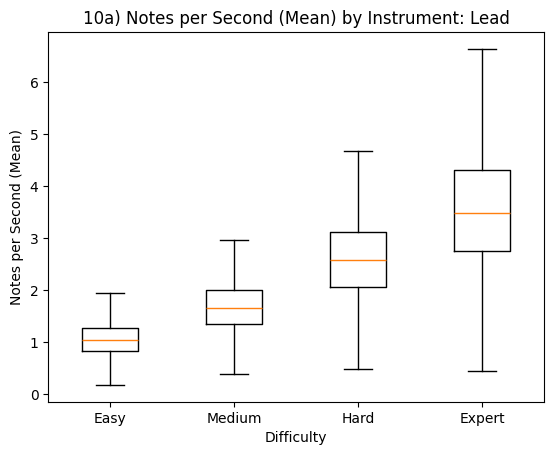

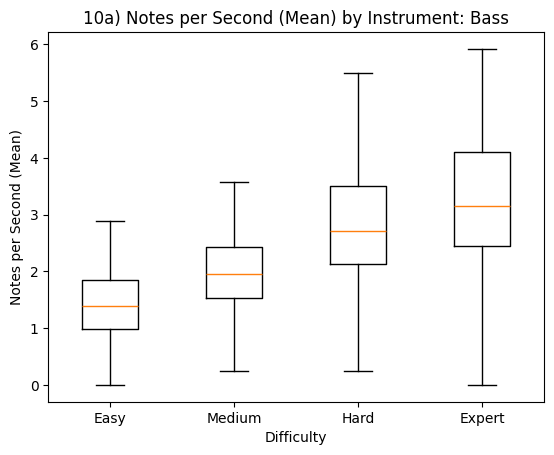

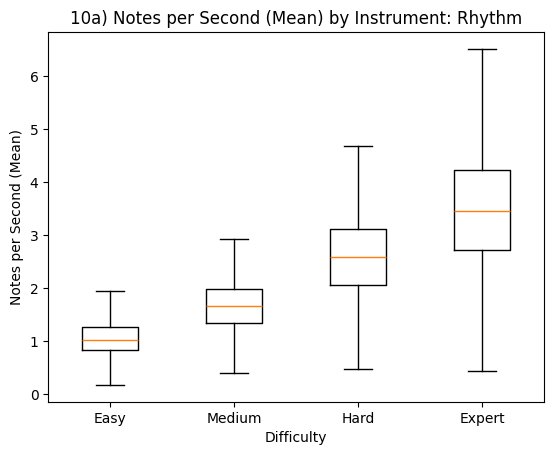

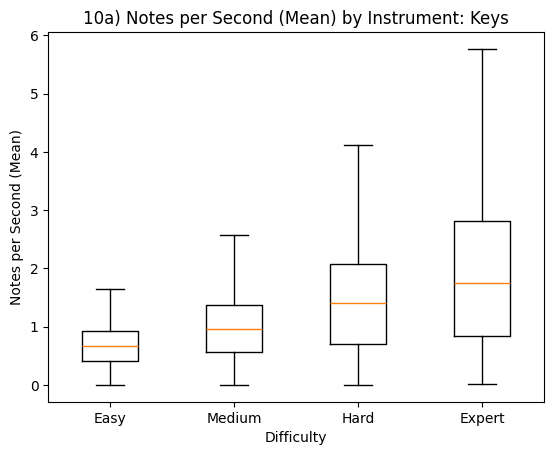

In [34]:
feat = "notes_per_second_mean"
insts = sorted(df_features["instrument_id"].dropna().unique())

for inst in insts:
    sub = df_features[df_features["instrument_id"] == inst]

    name = instrument_names.get(inst, str(inst))

    plot_box_by_difficulty(
        df=sub,
        y_col=feat,
        title=f"10a) Notes per Second (Mean) by Instrument: {name}",
        xlabel="Difficulty",
        ylabel="Notes per Second (Mean)"
    )

The box plots illustrate how notes per second scales with difficulty for each instrument, allowing comparison of density progression across tiers. For Lead, note density increases steadily from Easy through Expert, with clear separation between difficulty levels and a widening spread at higher tiers, indicating greater variability in harder charts. Bass shows a similar upward trend, with slightly higher medians than Lead at the lower difficulties and substantial expansion in variability at Hard and Expert. Rhythm demonstrates a smooth  increase across all tiers, with strong separation and moderate variance growth as difficulty increases. Keys also exhibit increasing density with difficulty, but overall medians remain lower than the other instruments. Adjacent tiers also display similar medians, further demonstraiting the mechanical simplicity of Keys.

     feature  difficulty_id instrument_a instrument_b       ks  cliffs_delta_med  cliffs_delta_ci_low  cliffs_delta_ci_high  n_a  n_b
 chord_ratio              2         Lead         Bass 0.825463          0.881043             0.850146              0.909482 5841  372
 chord_ratio              2         Bass       Rhythm 0.825029         -0.881006            -0.910580             -0.844767  372 5784
 chord_ratio              3         Bass       Rhythm 0.796860         -0.848690            -0.880923             -0.812922  383 6037
 chord_ratio              3         Lead         Bass 0.795476          0.847572             0.812212              0.885236 6398  383
 chord_ratio              1         Lead         Bass 0.786548          0.843153             0.808321              0.868915 5837  374
 chord_ratio              1         Bass       Rhythm 0.786521         -0.842177            -0.874222             -0.812119  374 5780
 chord_ratio              2         Bass         Keys 0.664014

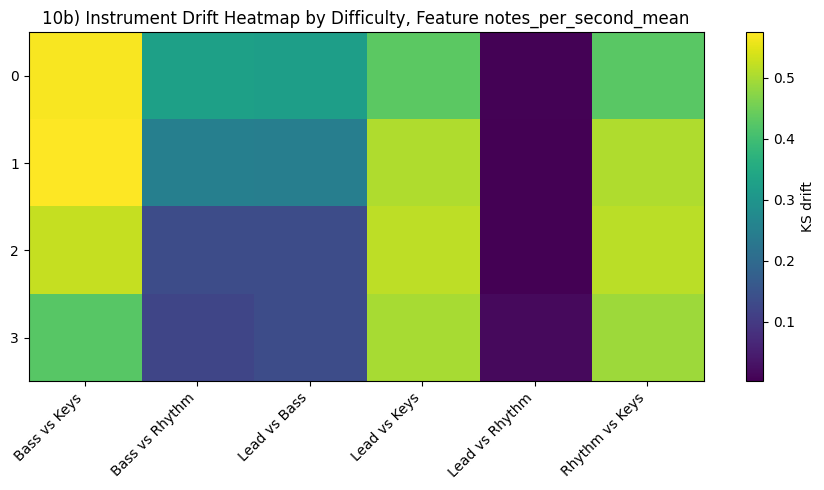

In [35]:
def ks_distance(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 10 or len(b) < 10:
        return np.nan
    a = np.sort(a); b = np.sort(b)
    x = np.sort(np.unique(np.concatenate([a, b])))
    cdf_a = np.searchsorted(a, x, side="right") / len(a)
    cdf_b = np.searchsorted(b, x, side="right") / len(b)
    return float(np.max(np.abs(cdf_a - cdf_b)))

def cliffs_delta(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 10 or len(b) < 10:
        return np.nan
    a = a.reshape(-1, 1)
    diffs = a - b.reshape(1, -1)
    return float((np.sum(diffs > 0) - np.sum(diffs < 0)) / diffs.size)

def bootstrap_ci(func, a, b, n=400, seed=0):
    rng = np.random.default_rng(seed)
    a = np.asarray(a); b = np.asarray(b)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 10 or len(b) < 10:
        return (np.nan, np.nan, np.nan)
    vals = []
    for _ in range(n):
        aa = rng.choice(a, size=len(a), replace=True)
        bb = rng.choice(b, size=len(b), replace=True)
        vals.append(func(aa, bb))
    vals = np.asarray(vals)
    return (float(np.nanmedian(vals)),
            float(np.nanpercentile(vals, 2.5)),
            float(np.nanpercentile(vals, 97.5)))

rows = []
for feat in sec10b_features:
    for d in sorted(df_features["difficulty_id"].dropna().unique()):
        sub = df_features[df_features["difficulty_id"] == d]
        insts = sorted(sub["instrument_id"].dropna().unique())
        for i in range(len(insts)):
            for j in range(i + 1, len(insts)):
                a = sub.loc[sub["instrument_id"] == insts[i], feat].dropna()
                b = sub.loc[sub["instrument_id"] == insts[j], feat].dropna()

                ks = ks_distance(a, b)
                cd_med, cd_lo, cd_hi = bootstrap_ci(cliffs_delta, a, b, n=400, seed=0)

                rows.append({
                    "feature": feat,
                    "difficulty_id": d,
                    "instrument_a": instrument_names.get(insts[i], str(insts[i])),
                    "instrument_b": instrument_names.get(insts[j], str(insts[j])),
                    "ks": ks,
                    "cliffs_delta_med": cd_med,
                    "cliffs_delta_ci_low": cd_lo,
                    "cliffs_delta_ci_high": cd_hi,
                    "n_a": len(a),
                    "n_b": len(b),
                })

drift = pd.DataFrame(rows)

print(
    drift.sort_values(["feature", "ks"], ascending=[True, False])
         .head(30)
         .to_string(index=False)
)

feat0 = "notes_per_second_mean"
tmp = drift[drift["feature"] == feat0].copy()
tmp["pair"] = tmp["instrument_a"] + " vs " + tmp["instrument_b"]
pivot = tmp.pivot_table(index="difficulty_id", columns="pair", values="ks", aggfunc="mean")

plot_heatmap(
    pivot.values,
    xlabels=list(pivot.columns),
    ylabels=[str(x) for x in pivot.index],
    title=f"10b) Instrument Drift Heatmap by Difficulty, Feature {feat0}",
    cbar_label="KS drift",
    figsize=(9, 5),
    xrot=45,
    ha="right",
)

For notes per second, several instrument pairs exhibit moderate to strong KS drift across difficulties, particularly comparisons involving Bass versus Lead and Bass versus Keys. These higher KS values indicate that note density distributions differ substantially between Bass and the other instruments at most tiers. In contrast, pairs such as Lead versus Rhythm show much smaller drift, suggesting that guitar parts behave more similarly in density progression.

The Kolmogorov–Smirnov, or KS, was used because it compares entire distributions rather than just means. KS measures the maximum difference between the cumulative distribution functions of two samples, producing a value between 0 and 1 where larger values indicate greater separation. This allows the analysis to capture differences in spread, skew, and tail behavior in note density across instruments, rather than focusing only on average density shifts. Overall, the results confirm that instrument type meaningfully conditions density distributions, especially between Bass and the guitar parts.

<h1>11. Feature Selection and Pruning Analysis</h1>

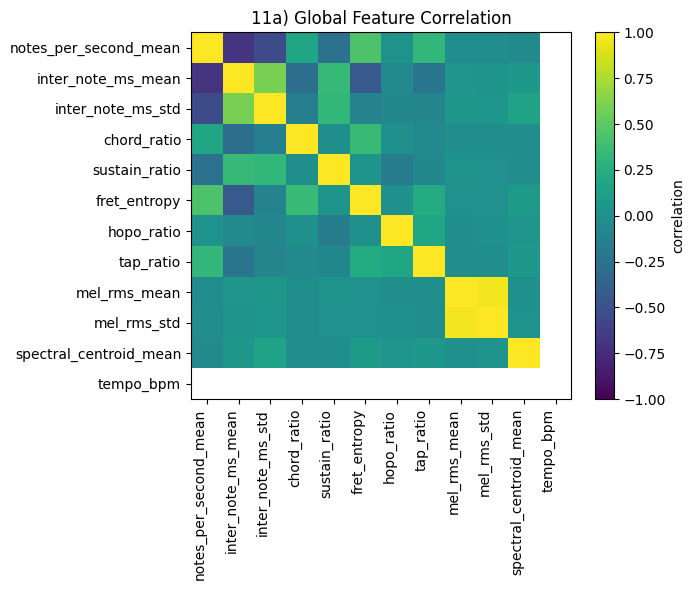

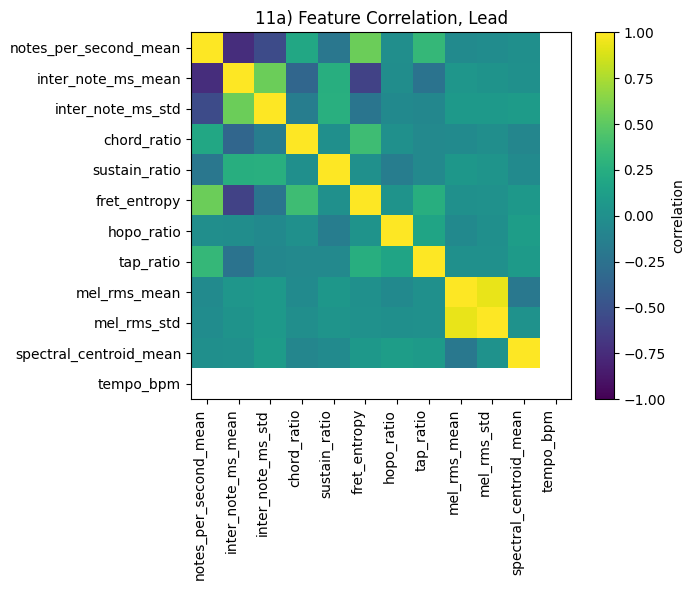

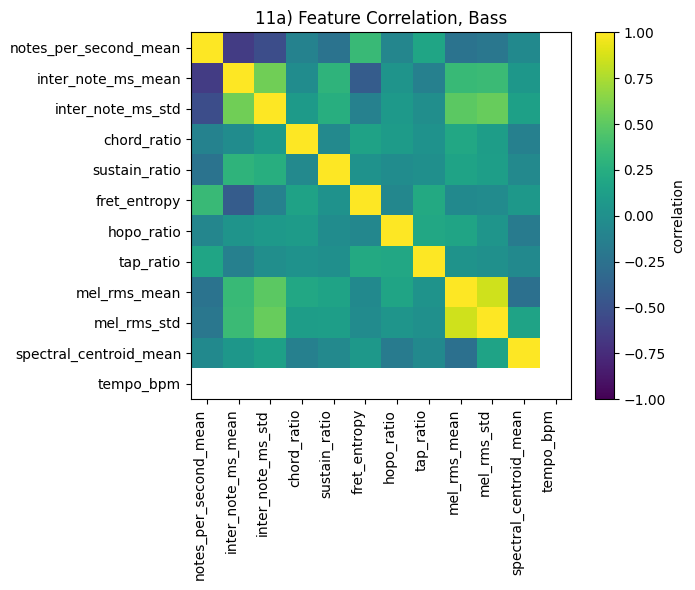

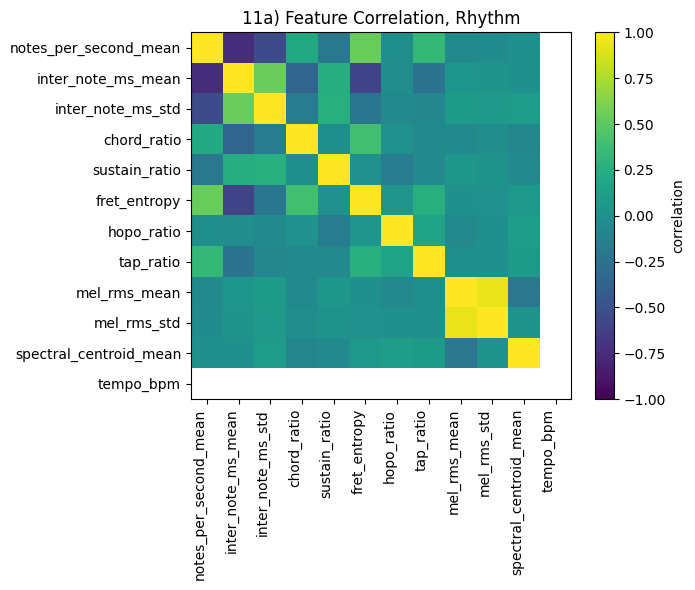

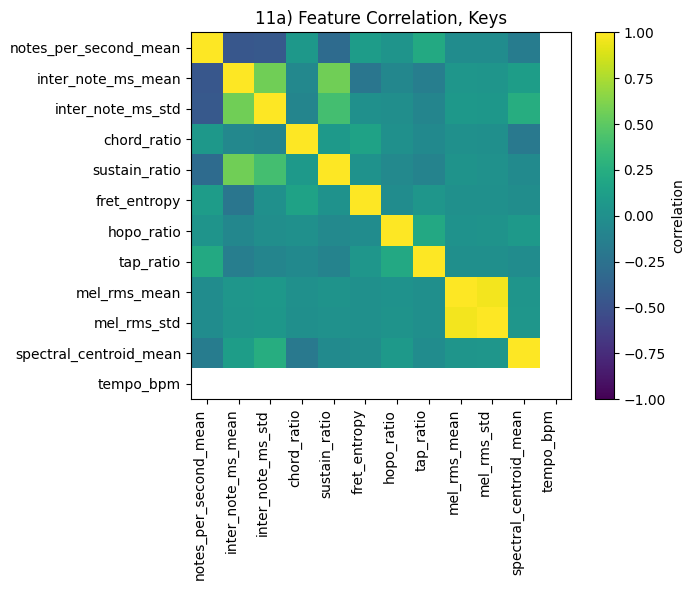

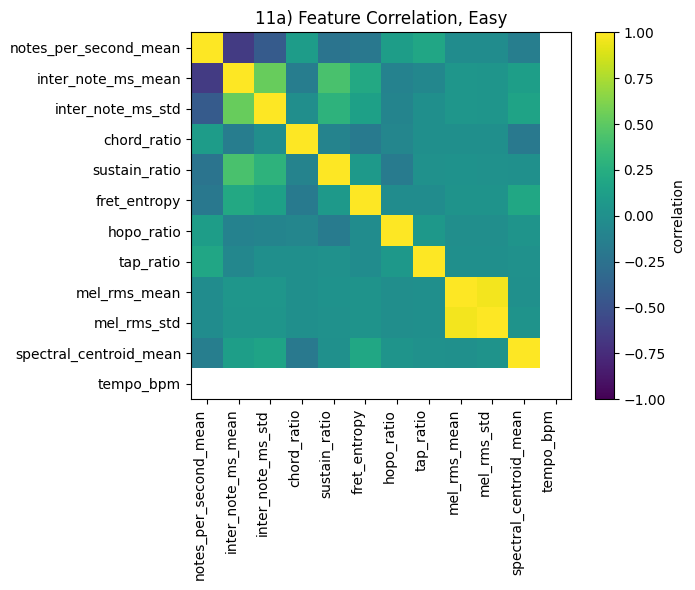

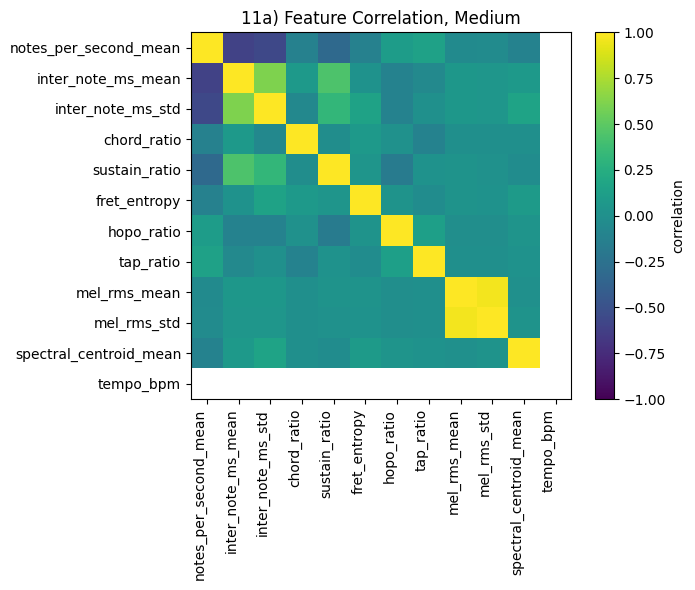

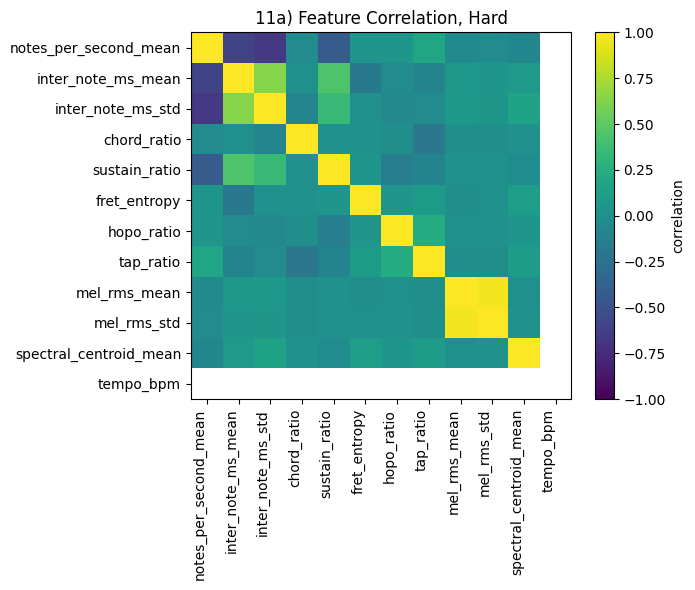

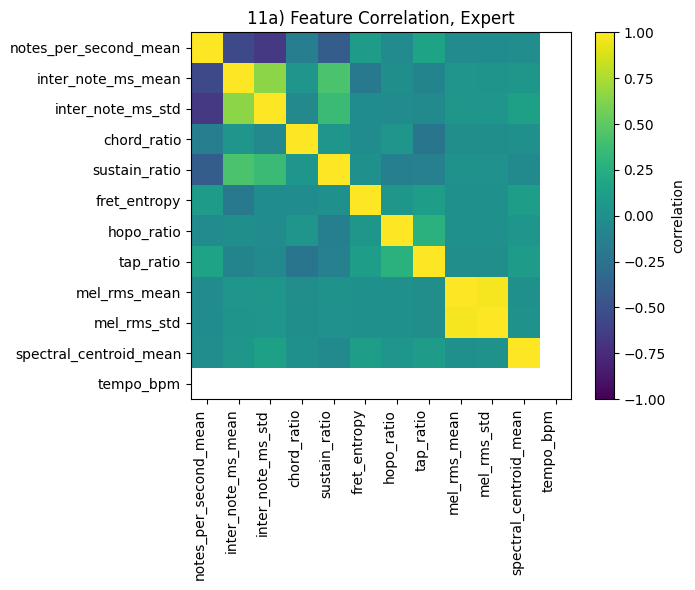

In [36]:
def plot_corr(df, title):
    C = df[sec11_features].corr()
    plot_heatmap(
        C.values,
        xlabels=sec11_features,
        ylabels=sec11_features,
        title=title,
        cbar_label="correlation",
        figsize=(7, 6),
        xrot=90,
        ha="right",
        vmin=-1,
        vmax=1,
    )

plot_corr(df_features, "11a) Global Feature Correlation")

for inst in sorted(df_features["instrument_id"].dropna().unique()):
    sub = df_features[df_features["instrument_id"] == inst]
    ins_name = instrument_names.get(inst, str(inst))
    if len(sub) > 50:
        plot_corr(sub, f"11a) Feature Correlation, {ins_name}")

for d in sorted(df_features["difficulty_id"].dropna().unique()):
    sub = df_features[df_features["difficulty_id"] == d]
    name = difficulty_names.get(d, str(d))
    if len(sub) > 50:
        plot_corr(sub, f"11a) Feature Correlation, {name}")

Globally, note density is strongly negatively correlated with inter note spacing and positively correlated with fret entropy and tap usage, confirming that faster charts tend to be more mechanically complex. Mel RMS mean and standard deviation are nearly perfectly correlated, indicating clear redundancy among audio energy features. Tempo remains largely uncorrelated with gameplay variables, suggesting it does not meaningfully track structural difficulty in this dataset.

For Lead, the same inverse relationship between density and spacing holds, with moderate positive alignment between density, entropy, and chord usage. Audio energy features remain tightly coupled and largely independent from structural gameplay measures. For Bass, density shows a somewhat stronger positive association with entropy and advanced mechanics compared to Lead, indicating a slightly more complexity driven pattern, though the overall structure remains similar. Rhythm closely mirrors the global pattern, with density acting as the central organizing variable and mel RMS features remaining redundant. Relationships among structural features are balanced and consistent. For Keys, density still anchors the correlation structure, but associations among complexity features are somewhat weaker, reflecting comparatively simpler or more constrained mechanical design.

Across difficulties, Easy exhibits the expected inverse density versus spacing relationship, with moderate coupling among complexity features but overall looser structural coordination. In Medium, correlations strengthen slightly between density, entropy, and mechanics, suggesting more coordinated scaling of complexity. Hard maintains positive alignment between density and entropy, with more consistent links among structural features as charts increase in intensity. In Expert, the strongest coupling appears between density, entropy, and advanced mechanics, indicating that higher difficulty increases complexity across multiple dimensions simultaneously, while tempo continues to remain largely independent.

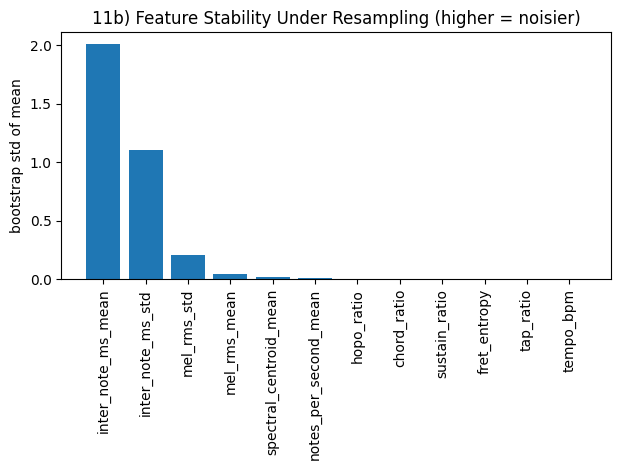

Bootstrap Stability Ranking (higher = less stable)
               feature  bootstrap_std
    inter_note_ms_mean       2.009748
     inter_note_ms_std       1.106334
           mel_rms_std       0.207440
          mel_rms_mean       0.039289
spectral_centroid_mean       0.021326
 notes_per_second_mean       0.007429
            hopo_ratio       0.001892
           chord_ratio       0.001535
         sustain_ratio       0.001239
          fret_entropy       0.001078
             tap_ratio       0.000359
             tempo_bpm       0.000000


In [37]:
rows = []
for col in sec11_features:
    x = df_features[col].dropna().values
    if len(x) < 200:
        continue
    rows.append({
        "feature": col,
        "bootstrap_std": bootstrap_std(x)
    })

stab = (
    pd.DataFrame(rows)
    .sort_values("bootstrap_std", ascending=False)
)

plt.bar(stab["feature"], stab["bootstrap_std"])
plt.xticks(rotation=90)
plt.ylabel("bootstrap std of mean")
plt.title("11b) Feature Stability Under Resampling (higher = noisier)")
plt.tight_layout()
plt.show()

print("Bootstrap Stability Ranking (higher = less stable)")
print(stab.to_string(index=False))


This stability plot shows which feature means change the most when you resample the dataset, where higher bootstrap standard deviation indicates a noisier, less stable estimate. Inter note timing features are the least stable, with inter note mean and inter note standard deviation dominating the instability, implying they are more sensitive to which charts are sampled and likely influenced by heavy tails or outliers. Audio features have moderate instability, especially mel RMS standard deviation, while most gameplay ratio features such as HOPO, chord, sustain, entropy, and tap are very stable under resampling. Tempo shows zero instability because it is effectively constant in the current data. Overall, the results suggest timing features are sensitive to outliers, while ratio based mechanics are reliable and consistent signals.

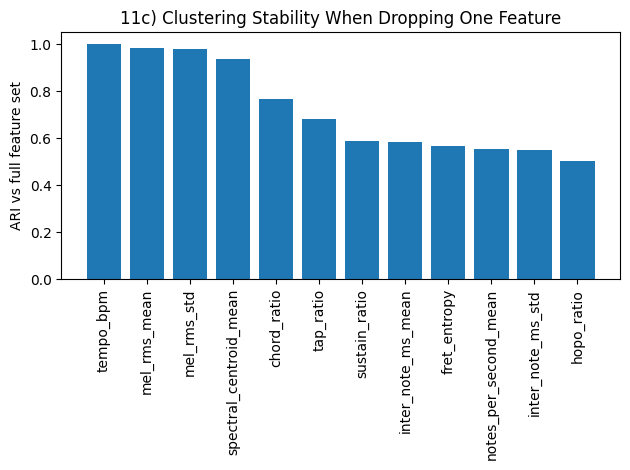

Leave-one-out clustering impact (higher ARI = less important feature)
       feature_dropped  ARI_vs_full
             tempo_bpm     1.000000
          mel_rms_mean     0.982967
           mel_rms_std     0.977082
spectral_centroid_mean     0.937178
           chord_ratio     0.766153
             tap_ratio     0.682140
         sustain_ratio     0.589181
    inter_note_ms_mean     0.584745
          fret_entropy     0.564904
 notes_per_second_mean     0.551615
     inter_note_ms_std     0.550132
            hopo_ratio     0.500688


In [38]:
base_labels = cluster_labels(sec11_features)

impact = []
for col in sec11_features:
    reduced = [c for c in sec11_features if c != col]
    labels = cluster_labels(reduced)
    ari = adjusted_rand_score(base_labels, labels)
    impact.append({
        "feature_dropped": col,
        "ARI_vs_full": ari
    })

impact_df = (
    pd.DataFrame(impact)
    .sort_values("ARI_vs_full", ascending=False)
)

plt.bar(impact_df["feature_dropped"], impact_df["ARI_vs_full"])
plt.xticks(rotation=90)
plt.ylabel("ARI vs full feature set")
plt.title("11c) Clustering Stability When Dropping One Feature")
plt.tight_layout()
plt.show()

print("Leave-one-out clustering impact (higher ARI = less important feature)")
print(impact_df.to_string(index=False))


Gameplay and structural timing features are the primary drivers of cluster formation. Removing tempo or RMS based audio features barely alters cluster assignments, indicating they contribute little unique information to the clustering solution. In contrast, dropping HOPO ratio, inter note timing measures, notes per second, fret entropy, or sustain ratio substantially changes cluster structure, demonstrating that density, spacing, and mechanic usage define stylistic groupings. Overall, clustering is driven predominantly by structural gameplay features, while audio features provide minimal additional separation in this context.

C:\Users\Susan\AppData\Local\Temp\ipykernel_47336\598871054.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(sub["difficulty_id"], sub[col])


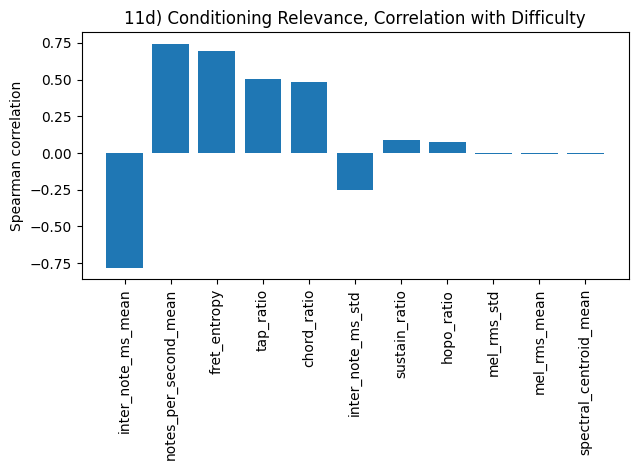

Conditioning relevance ranking
               feature  spearman_vs_difficulty  abs_corr
    inter_note_ms_mean               -0.781675  0.781675
 notes_per_second_mean                0.745203  0.745203
          fret_entropy                0.697761  0.697761
             tap_ratio                0.506403  0.506403
           chord_ratio                0.483076  0.483076
     inter_note_ms_std               -0.253697  0.253697
         sustain_ratio                0.086214  0.086214
            hopo_ratio                0.072779  0.072779
           mel_rms_std               -0.006034  0.006034
          mel_rms_mean               -0.005936  0.005936
spectral_centroid_mean               -0.003955  0.003955
             tempo_bpm                     NaN       NaN


In [39]:
rows = []
for col in sec11_features:
    sub = df_features[["difficulty_id", col]].dropna()
    if len(sub) < 200:
        continue
    r, _ = spearmanr(sub["difficulty_id"], sub[col])
    rows.append({
        "feature": col,
        "spearman_vs_difficulty": r
    })

rel = (
    pd.DataFrame(rows)
    .assign(abs_corr=lambda d: d["spearman_vs_difficulty"].abs())
    .sort_values("abs_corr", ascending=False)
)

plt.bar(rel["feature"], rel["spearman_vs_difficulty"])
plt.xticks(rotation=90)
plt.ylabel("Spearman correlation")
plt.title("11d) Conditioning Relevance, Correlation with Difficulty")
plt.tight_layout()
plt.show()

print("Conditioning relevance ranking")
print(rel.to_string(index=False))


Difficulty is most strongly associated with note spacing and density, with inter note mean having a large negative correlation and notes per second having a large positive correlation. Fret entropy also correlates strongly with difficulty, indicating harder charts use a wider spread of frets. Tap ratio and chord ratio show moderate positive correlations, suggesting advanced mechanics and chord usage increase with difficulty but are secondary to raw speed and complexity. Inter note variability has a weaker negative relationship, while sustain and HOPO ratios have only small positive correlations. Audio features show near zero correlation with difficulty, and tempo is missing or constant, so it provides no usable difficulty signal.

<h1>12. Genre Structure and Clustering Analysis</h1>

difficulty_id,0,1,2,3
genre_id,,,,
0,4,4,4,7
1,6027,6018,6015,6265
2,2680,2680,2686,3026
3,1302,1302,1302,1346
4,815,813,813,839
5,404,404,404,447
6,4,4,4,13
7,714,714,714,718
8,301,301,301,302


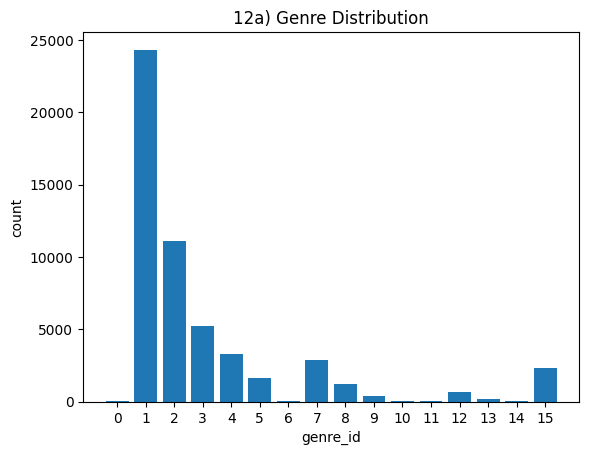

In [40]:
ct = pd.crosstab(df_features["genre_id"], df_features["difficulty_id"])
display(ct)

genre_counts = df_features["genre_id"].value_counts().sort_index()

plt.bar(genre_counts.index.astype(str), genre_counts.values)
plt.xlabel("genre_id")
plt.ylabel("count")
plt.title("12a) Genre Distribution")
plt.show()


The dataset is heavily imbalanced by genre, with genre 1 dominating by a large margin, followed by genres 2 and 3, while many other genres have very few samples. The distribution across difficulties is fairly consistent within each genre, meaning each major genre is represented at all difficulty levels in roughly similar proportions. However, the long tail of low count genres could bias modeling and evaluation toward the dominant genres, suggesting that weighting, stratified sampling, or genre conditioning may be necessary for balanced tab generation.


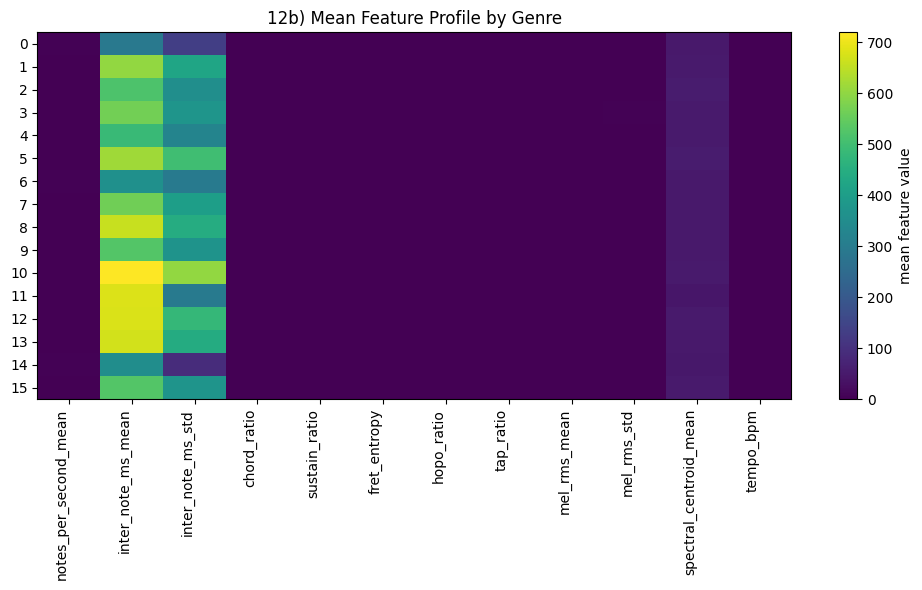

In [41]:
genre_means = df_features.groupby("genre_id")[sec12_features].mean()

plot_heatmap(
    genre_means.values,
    xlabels=sec12_features,
    ylabels=list(genre_means.index),
    title="12b) Mean Feature Profile by Genre",
    cbar_label="mean feature value",
    figsize=(10, 6),
    xrot=90,
    ha="right",
)

Genre level averages show meaningful structural differences across styles. Note density and inter note timing vary substantially by genre, indicating some genres are consistently faster and more tightly spaced than others. Inter note variability also differs, suggesting different rhythmic consistency patterns across genres. In contrast, most mechanical ratios such as chord, sustain, HOPO, and tap show relatively smaller variation at the genre mean level compared to timing features. Audio features, particularly spectral centroid and mel RMS, also vary by genre, reflecting tonal differences, but they do not dominate gameplay structure. This indicates that genre primarily influences speed and rhythmic spacing, while mechanic usage varies more within genre than across genres, suggesting genre is a strong conditioning variable for pacing but a weaker one for detailed mechanic composition.

C:\Users\Susan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [11] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Susan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


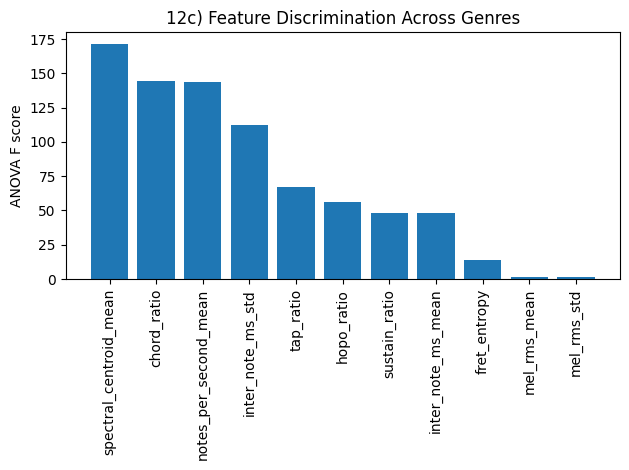

                   feature     F_score
10  spectral_centroid_mean  171.421199
3              chord_ratio  144.498349
0    notes_per_second_mean  143.893252
2        inter_note_ms_std  112.106677
7                tap_ratio   66.849835
6               hopo_ratio   55.953749
4            sustain_ratio   48.095975
1       inter_note_ms_mean   47.821669
5             fret_entropy   14.235510
8             mel_rms_mean    1.377442
9              mel_rms_std    1.353405
11               tempo_bpm         NaN


In [42]:
X = clean_df(df_features, sec12_features)
y = df_features.loc[X.index, "genre_id"]

f_vals, p_vals = f_classif(X, y)

anova_df = pd.DataFrame({
    "feature": sec12_features,
    "F_score": f_vals,
}).sort_values("F_score", ascending=False)

plt.bar(anova_df["feature"], anova_df["F_score"])
plt.xticks(rotation=90)
plt.ylabel("ANOVA F score")
plt.title("12c) Feature Discrimination Across Genres")
plt.tight_layout()
plt.show()

print(anova_df)


Genre differences are most strongly captured by spectral centroid, making tonal brightness the top distinguishing feature. Gameplay features also show meaningful genre separation, especially chord ratio and note density, followed by inter note variability and tap usage. Sustain and HOPO ratios contribute moderately, while fret entropy has limited discriminatory power. Audio energy features such as mel RMS mean and standard deviation do not contribute in any meaningful way.

In [43]:
X = clean_df(df_features, sec12_features)
y = df_features.loc[X.index, "genre_id"]

scaled = standardize(X)
k = len(np.unique(y))
labels = kmeans_labels(scaled, k)

ari = adjusted_rand_score(y, labels)
sil = silhouette_score(scaled, labels)

print("12d) Clustering vs Genre")
print("Adjusted Rand Index:", ari)
print("Silhouette score:", sil)



12d) Clustering vs Genre
Adjusted Rand Index: 0.008500950559756085
Silhouette score: 0.18563547683992548


Clustering structure does not align with genre. The Adjusted Rand Index is essentially zero, indicating almost no agreement between KMeans clusters and genre labels. The silhouette score is modest, meaning clusters exist in feature space, but they do not correspond to genre boundaries.

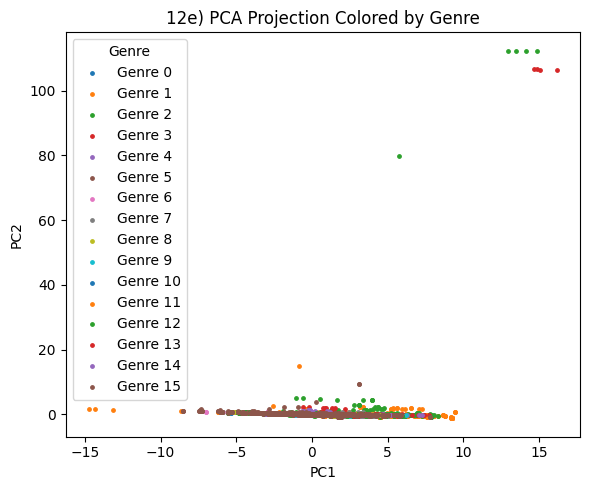

In [44]:
Z = pca2(scaled, n_components=2, random_state=0)

plt.figure(figsize=(6, 5))

unique_genres = sorted(np.unique(y))

for g in unique_genres:
    idx = y == g
    plt.scatter(
        Z[idx, 0],
        Z[idx, 1],
        s=6,
        label=f"Genre {g}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("12e) PCA Projection Colored by Genre")
plt.legend(title="Genre")
plt.tight_layout()
plt.show()

The PCA projection shows heavy overlap between genres in the main structural feature space. Most genres cluster in the same dense region along PC1 and PC2, with no clear genre separated boundaries. A few outliers appear at extreme PC2 values, but they are sparse and do not form distinct genre clusters. Overall, the genre does not form clean separable groups in the primary gameplay feature dimensions, reinforcing that structural chart style is largely independent of musical genre.